In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap

C:\Users\Carlos\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Funções

#função tratar nulos
def tratarNulos(dados):
    dataset = dados.copy()  # evita problemas de referência
    
    # Colunas numéricas que representam categorias
    colunas_categoricas_numericas = [
        'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA',
        'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU',
        'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC','Q001','Q002','Q003','Q004','Q005','Q006',
        'Q007','Q008','Q009','Q010','Q011','Q012','Q013','Q014','Q015','Q016','Q017','Q018','Q019','Q020','Q021','Q022','Q023','Q024','Q025'
    ]
    
    for col in dataset.columns:
        if dataset[col].isnull().any():  # só trata se houver nulos
            if col in colunas_categoricas_numericas:
                # Para categóricas → moda
                moda = dataset[col].mode()
                if not moda.empty:
                    dataset[col] = dataset[col].fillna(moda.iloc[0])
            else:
                # Para numéricas contínuas → média
                media = dataset[col].mean()
                dataset[col] = dataset[col].fillna(media)
    
    return dataset



#Função analisar importância das features de forma agregada
def analisar_importancia_features_agregada(modelo, clf, titulo, top_n=None):
    """
    Exibe a importância das features de um modelo DecisionTreeClassifier,
    somando as importâncias das dummies das features categóricas.

    Parâmetros:
    - modelo: pipeline treinado (com preprocessador + classificador)
    - clf: classificador treinado (ex: DecisionTreeClassifier)
    - categoricas: lista de colunas categóricas originais
    - top_n: se quiser mostrar só as N variáveis mais importantes (opcional)

    Retorna:
    - df_agregado: DataFrame com importância agregada por feature
    """

    categoricas = ['TP_SEXO', 'Q001','Q002','Q003','Q004', 'Q007','Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019','Q020','Q021','Q022','Q023','Q024','Q025']
    # Extrair nomes das features pós-transformação
    nomes_features = modelo.named_steps['preprocessador'].get_feature_names_out()
    
    # Importâncias
    importances = clf.feature_importances_
    
    # Criar DataFrame
    df = pd.DataFrame({
        'feature_expandida': nomes_features,
        'importancia': importances
    })
    
    # Inicializar coluna de feature original
    df['feature_original'] = df['feature_expandida']
    
    # Mapear dummies categóricas para a feature original
    for cat in categoricas:
        mask = df['feature_expandida'].str.contains(f"__{cat}_")
        df.loc[mask, 'feature_original'] = cat
    
    # Agregar importâncias por feature original
    df_agregado = df.groupby('feature_original')['importancia'].sum().sort_values(ascending=False)
    # 🔧 REMOVER PREFIXO "num_"
    df_agregado.index = df_agregado.index.str.replace(r'^.*__', '', regex=True)
    
    # Filtrar top_n se necessário
    if top_n:
        df_agregado = df_agregado.head(top_n)
    
    # Print em texto
    print("Importância das features (agregada):")
    for feat, imp in df_agregado.items():
        print(f"Feature {feat}: {imp:.4f}")
    
    # Gráfico
    plt.figure(figsize=(10,6))
    plt.barh(df_agregado.index, df_agregado.values)   # <-- barras horizontais
    plt.xlabel("Importância")                         # título do eixo X
    plt.ylabel("Features")                            # título do eixo Y
    plt.title(f"Importância das Features {titulo}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return df_agregado


#Função analisar features de forma individual
def analisar_importancia_features(modelo, clf, titulo, top_n=None):
    """
    Exibe a importância individual das features (sem agregação) 
    de um modelo DecisionTreeClassifier treinado dentro de um pipeline.

    Parâmetros:
    - modelo: pipeline treinado (com preprocessador + classificador)
    - clf: classificador treinado (ex: DecisionTreeClassifier)
    - top_n: se quiser mostrar só as N variáveis mais importantes (opcional)

    Retorna:
    - df_importancias: DataFrame com importâncias individuais
    """

    # Extrair nomes das features após o pré-processamento
    nomes_features = modelo.named_steps['preprocessador'].get_feature_names_out()
    # 🔧 REMOVER prefixos do ColumnTransformer (cat__, num__, etc.)
    nomes_features = pd.Series(nomes_features).str.replace(r'^.*__', '', regex=True).values

    # Pegar as importâncias
    importances = clf.feature_importances_

    # Criar DataFrame
    df_importancias = pd.DataFrame({
        'feature': nomes_features,
        'importancia': importances
    }).sort_values(by='importancia', ascending=False)

    # Filtrar top_n se solicitado
    if top_n:
        df_importancias = df_importancias.head(top_n)

    # Print simples
    print("Importância das features (sem agregação):")
    for feat, imp in zip(df_importancias['feature'], df_importancias['importancia']):
        print(f"{feat}: {imp:.4f}")

    # Gráfico
    plt.figure(figsize=(10,6))
    plt.barh(df_importancias['feature'], df_importancias['importancia'])
    plt.xlabel("Importância")
    plt.ylabel("Feature")
    plt.title(f"Importância Individual das Features {titulo}")
    plt.gca().invert_yaxis()  # deixa a mais importante no topo
    plt.tight_layout()
    plt.show()

    return df_importancias


#Função analisar desempenhos estatísticos(media, mediana, desvio padrão, quartis, valor minimo, valor maximo, amplitude e coeficiente de variação) pra cada classe de renda social
def analisar_desempenho_por_classe(
    dataset, 
    nome_dataset, 
    notas=['NU_NOTA_CH','NU_NOTA_CN','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO'],
    nivel_confianca=0.95
):
    """
    Analisa estatísticas das notas por classe social e
    adiciona intervalo de confiança da média ao boxplot.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import norm

    # Criar coluna de média das notas
    dataset['media_notas'] = dataset[notas].mean(axis=1)

    # Funções auxiliares
    def calc_amplitude(x):
        return x.max() - x.min()

    def calc_cv(x):
        return (x.std() / x.mean()) * 100 if x.mean() != 0 else np.nan

    # Agrupar por classe social
    resumo = dataset.groupby('faixa_renda')['media_notas'].agg(
        media='mean',
        mediana='median',
        desvio_padrao='std',
        n='count',
        variancia='var',
        q1=lambda x: np.percentile(x, 25),
        q3=lambda x: np.percentile(x, 75),
        valor_minimo='min',
        valor_maximo='max',
        amplitude=calc_amplitude,
        coef_var=calc_cv
    ).reset_index()

    # Ordem correta das classes
    ordem_classes = {
        "Até 2 salários mínimos": 1,
        "De 2 a 3 salários mínimos": 2,
        "De 3 a 6 salários mínimos": 3,
        "De 6 a 10 salários mínimos": 4,
        "De 10 a 15 salários mínimos": 5,
        "Acima de 15 salários mínimos": 6
    }

    def mapear_ordem(classe):
        for nome, ordem in ordem_classes.items():
            if nome in classe:
                return ordem
        return np.nan

    resumo['ordem'] = resumo['faixa_renda'].apply(mapear_ordem)
    resumo = resumo.sort_values('ordem')

    # 🔢 Intervalo de confiança
    z = norm.ppf(1 - (1 - nivel_confianca) / 2)

    resumo['erro_padrao'] = resumo['desvio_padrao'] / np.sqrt(resumo['n'])
    resumo['ic_inf'] = resumo['media'] - z * resumo['erro_padrao']
    resumo['ic_sup'] = resumo['media'] + z * resumo['erro_padrao']

  

    # 📊 Gráfico
    plt.figure(figsize=(12, 6))

    dados_plot = [
        dataset.loc[dataset['faixa_renda'] == classe, 'media_notas']
        for classe in resumo['faixa_renda']
    ]

    plt.boxplot(
        dados_plot,
        vert=False,
        labels=resumo['faixa_renda'],
        showfliers=True
    )

    # 🔴 Intervalo de confiança sobreposto
    y_pos = np.arange(1, len(resumo) + 1)

    plt.hlines(
        y=y_pos,
        xmin=resumo['ic_inf'],
        xmax=resumo['ic_sup'],
        colors='red',
        linewidth=3,
        label='IC 95% da média'
    )

    # Ponto da média
    plt.plot(
        resumo['media'],
        y_pos,
        'ro'
    )

    plt.xlabel("Distribuição da média das notas")
    plt.ylabel("Faixa de renda")
    plt.title(f"Distribuição das notas por classe social {nome_dataset}")
    plt.legend()

    plt.tight_layout()
    plt.show()

    return resumo


def shap_multiclasses(df_transformado, clf, ano):
    
    amostra = df_transformado.sample(200, random_state=42)
    # compute SHAP values
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(amostra)
    class_names = [
    'Até 2 salários mínimos',
    'De 2 a 3 salários mínimos',
    'De 3 a 6 salários mínimos',
    'De 6 a 10 salários mínimos',
    'De 10 a 15 salários mínimos',
    'Acima de 15 salários mínimos'
    ]
    shap.summary_plot(shap_values, amostra.values, plot_type="bar", class_names= class_names, class_inds=list(range(len(class_names))), feature_names= amostra.columns, show=False)

    # Título centralizado na FIGURA inteira
    plt.suptitle(
    f"Importância das variáveis por faixa de renda {ano}",
    fontsize=14,
    y=0.98
    )

    # Ajusta margens para acomodar nomes das features
    plt.subplots_adjust(left=0.32, top=0.92)

    plt.show()

    

#Função criação do modelo, clf, preprocessador
def treinar_modelo(dataset):

    # 1. Separar X e y
    X = dataset.drop(columns=['faixa_renda'])
    y = dataset['faixa_renda']

    # 2. Identificar colunas categóricas e numéricas
    categoricas = ['TP_SEXO', 'Q001','Q002','Q003','Q004', 'Q007','Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019','Q020','Q021','Q022','Q023','Q024','Q025']
    numericas = ['Q005','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC',
                'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_FAIXA_ETARIA', 'TP_ANO_CONCLUIU'] 

    # 3. Pré-processamento (OneHot para categóricas, passthrough para numéricas)
    preprocessador = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
            ('num', 'passthrough', numericas)
        ]
    )

    clf = DecisionTreeClassifier(
        criterion="gini",
        splitter="best",
        max_depth=None,          # sem limite de profundidade
        min_samples_split=2,     # pode dividir até com 2 amostras
        min_samples_leaf=1,      # folhas com 1 amostra
        max_features=None,       # usa todos os atributos
        random_state=42
    )

    # 4. Criar pipeline com pré-processamento + modelo
    modelo = Pipeline(steps=[
        ('preprocessador', preprocessador),
        ('classificador', clf) 
    ])



    # 6. Treinar modelo
    modelo.fit(X, y)

    # 7. Avaliar
    y_pred = modelo.predict(X)
    print("Acurácia:", accuracy_score(y, y_pred))
    print("\nRelatório de classificação:\n", classification_report(y, y_pred))
    print("\nMatriz de confusão:\n", confusion_matrix(y, y_pred))

     # 👇 Aqui ocorre a transformação usando o preprocessador já treinado
    X_transformado = modelo.named_steps['preprocessador'].transform(X)

    # 👇 Recuperando os nomes das colunas após OneHotEncoding
    ohe = modelo.named_steps['preprocessador'].named_transformers_['cat']
    nomes_ohe = list(ohe.get_feature_names_out(categoricas))

    # Combine OHE + numéricas
    colunas_final = nomes_ohe + numericas 

    # Convertendo para DataFrame final
    df_transformado = pd.DataFrame(X_transformado, columns=colunas_final)

    return modelo, clf, df_transformado

In [3]:
caminho_arquivo = './dados/MICRODADOS_ENEM_2023.csv'
data = pd.read_csv(caminho_arquivo, encoding='latin1', sep=';')
num_columns = data.shape[1]
num_rows = data.shape[0]
print(f"Número de colunas: {num_columns}")
print(f"Número de linhas: {num_rows}")
data.head()

Número de colunas: 76
Número de linhas: 3933955


,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,...,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,...,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,...,B,A,A,B,A,A,A,A,A,B
3,210060214087,2023,2,F,1,3,1,2,0,2,...,A,A,A,B,A,A,D,A,A,B
4,210059980948,2023,3,F,1,3,1,2,0,2,...,A,A,A,B,A,A,B,A,A,A


In [4]:
dados_selecionados = data[['TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'Q001','Q002','Q003','Q004','Q005','Q006', 'Q007','Q008','Q009','Q010','Q011',
                       'Q012','Q013','Q014','Q015','Q016',
                       'Q017','Q018','Q019','Q020','Q021','Q022','Q023','Q024','Q025']]

In [5]:
print("Antes:")
print(dados_selecionados.isnull().sum()[data.isnull().sum() > 0])
dataset_sem_nulos  = tratarNulos(dados_selecionados)
print("\nDepois:")
print(dataset_sem_nulos.isnull().sum()[dataset_sem_nulos.isnull().sum() > 0])

Antes:
TP_ENSINO             2594874
TP_LOCALIZACAO_ESC    2975449
NU_NOTA_CN            1241528
NU_NOTA_CH            1111312
NU_NOTA_LC            1111312
NU_NOTA_MT            1241528
NU_NOTA_REDACAO       1111312
dtype: int64

Depois:
Series([], dtype: int64)


In [6]:
# Dicionário para mapear as respostas da questão Q006 (faixa de renda) em faixa de renda
mapa_renda = {
    'A': 'Até 2 salários mínimos',
    'B': 'Até 2 salários mínimos',
    'C': 'Até 2 salários mínimos',
    'D': 'Até 2 salários mínimos',
    'E': 'De 2 a 3 salários mínimos',
    'F': 'De 3 a 6 salários mínimos',
    'G': 'De 3 a 6 salários mínimos',
    'H': 'De 3 a 6 salários mínimos',
    'I': 'De 3 a 6 salários mínimos',
    'J': 'De 3 a 6 salários mínimos',
    'K': 'De 6 a 10 salários mínimos',
    'L': 'De 6 a 10 salários mínimos',
    'M': 'De 6 a 10 salários mínimos',
    'N': 'De 6 a 10 salários mínimos',
    'O': 'De 10 a 15 salários mínimos',
    'P': 'De 10 a 15 salários mínimos',
    'Q': 'Acima de 15 salários mínimos'
}

# Criar nova coluna 'faixa_renda' baseada na resposta da questão Q006
dataset_sem_nulos['faixa_renda'] = dataset_sem_nulos['Q006'].map(mapa_renda)
dataset_sem_nulos = dataset_sem_nulos.drop(columns=['Q006'])

In [7]:
modelo, clf, df_transformado = treinar_modelo(dataset_sem_nulos)

Acurácia: 0.9998914578331476

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     51489
      Até 2 salários mínimos       1.00      1.00      1.00   2601632
 De 10 a 15 salários mínimos       1.00      1.00      1.00     79323
   De 2 a 3 salários mínimos       1.00      1.00      1.00    293994
   De 3 a 6 salários mínimos       1.00      1.00      1.00    733099
  De 6 a 10 salários mínimos       1.00      1.00      1.00    174418

                    accuracy                           1.00   3933955
                   macro avg       1.00      1.00      1.00   3933955
                weighted avg       1.00      1.00      1.00   3933955


Matriz de confusão:
 [[  51489       0       0       0       0       0]
 [      0 2601628       0       1       3       0]
 [      0       0   79323       0       0       0]
 [      0     219       0  293774       1       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1753
Feature NU_NOTA_MT: 0.0593
Feature NU_NOTA_CH: 0.0545
Feature NU_NOTA_LC: 0.0543
Feature NU_NOTA_CN: 0.0536
Feature Q024: 0.0485
Feature Q008: 0.0484
Feature NU_NOTA_REDACAO: 0.0412
Feature Q001: 0.0366
Feature Q004: 0.0350
Feature Q003: 0.0332
Feature Q002: 0.0320
Feature TP_FAIXA_ETARIA: 0.0303
Feature Q005: 0.0258
Feature Q019: 0.0223
Feature TP_ANO_CONCLUIU: 0.0204
Feature Q009: 0.0203
Feature Q022: 0.0198
Feature TP_COR_RACA: 0.0178
Feature Q007: 0.0177


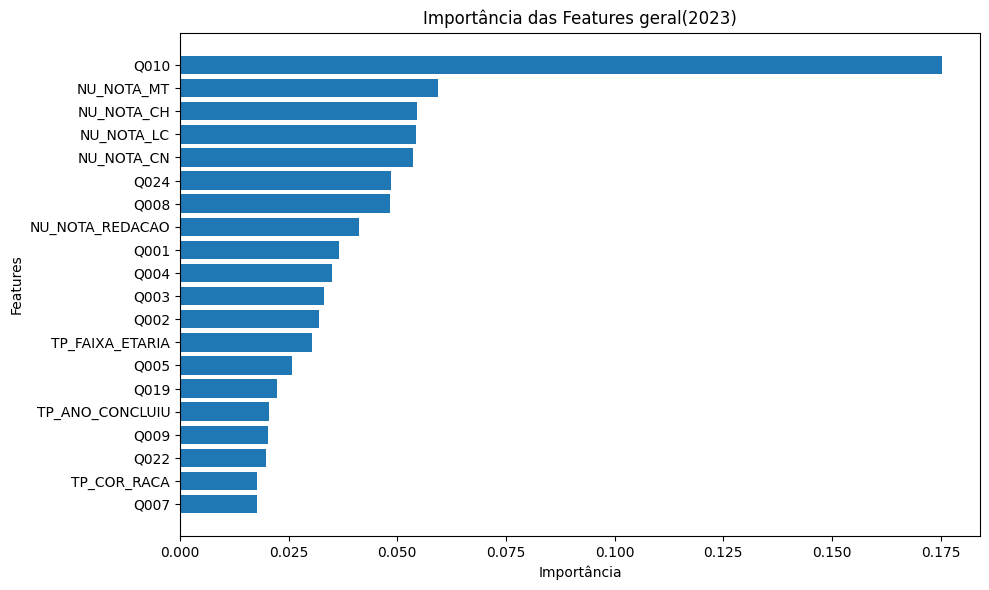

In [8]:
df_importancia = analisar_importancia_features_agregada(modelo, clf, "geral(2023)", 20)


Importância das features (sem agregação):
Q010_A: 0.1674
NU_NOTA_MT: 0.0593
NU_NOTA_CH: 0.0545
NU_NOTA_LC: 0.0543
NU_NOTA_CN: 0.0536
NU_NOTA_REDACAO: 0.0412
Q008_B: 0.0404
Q024_A: 0.0322
TP_FAIXA_ETARIA: 0.0303
Q005: 0.0258
TP_ANO_CONCLUIU: 0.0204
TP_COR_RACA: 0.0178
Q004_D: 0.0156
Q007_A: 0.0144
Q024_B: 0.0128
TP_ESCOLA: 0.0094
Q003_E: 0.0093
Q014_A: 0.0085
TP_ST_CONCLUSAO: 0.0082
Q003_D: 0.0079


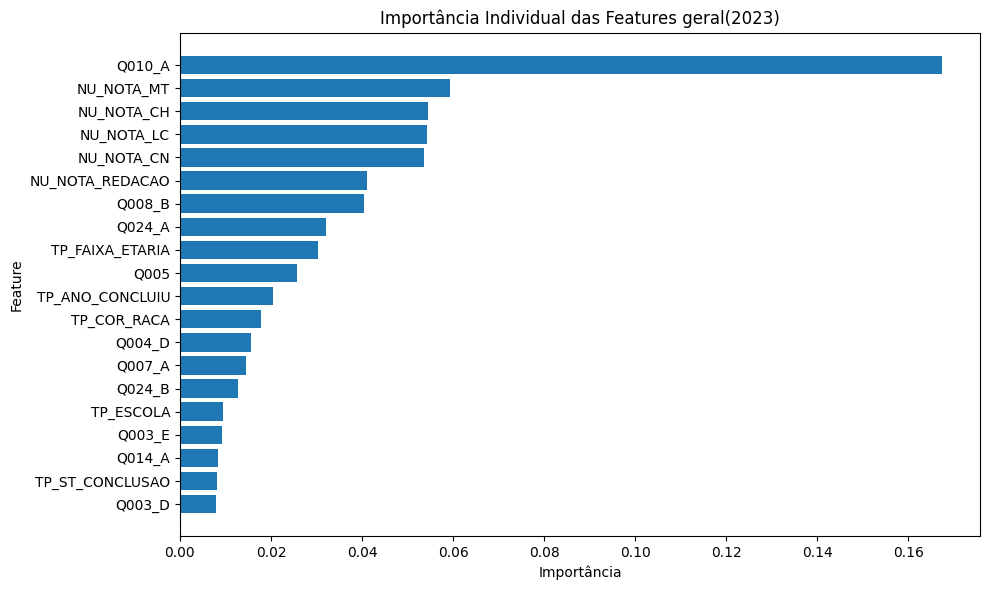

In [9]:
df_importancias_individuais = analisar_importancia_features(modelo, clf, "geral(2023)", top_n=20)


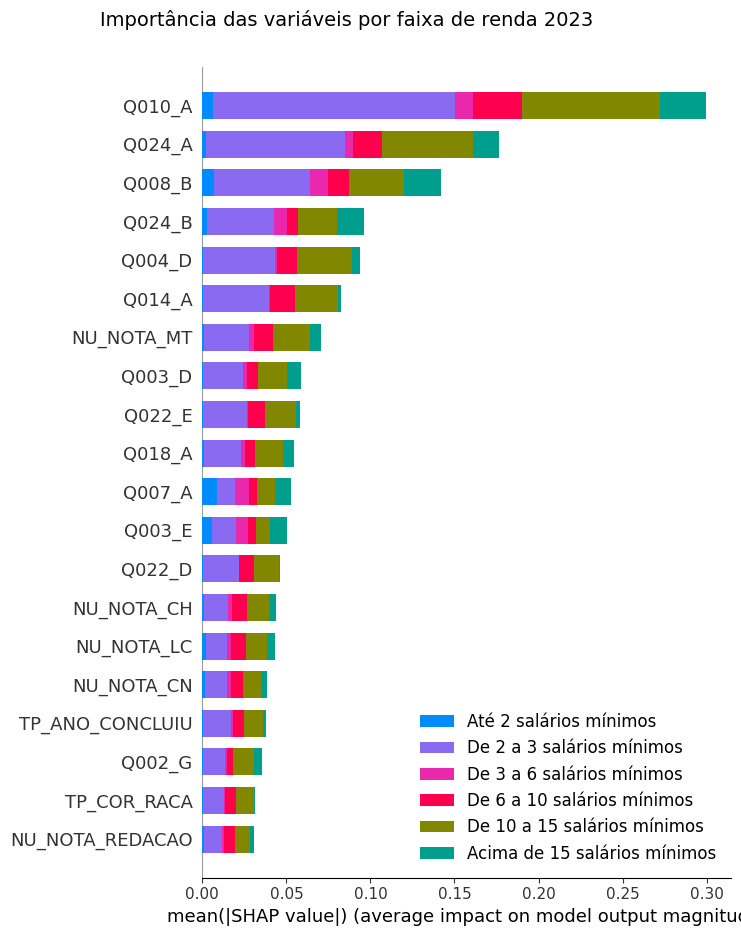

In [10]:
shap_multiclasses(df_transformado, clf, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


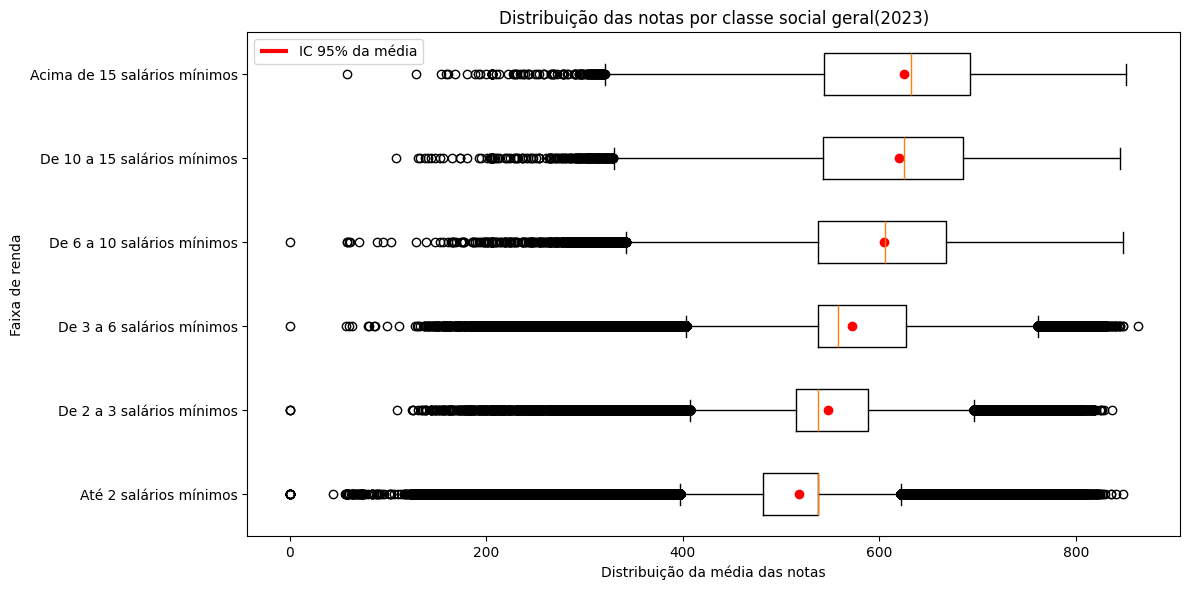

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,518.209141,537.777315,71.151907,2601632,5062.593873,481.500000,537.777315,0.00,847.54,847.54,13.730346,1,0.044113,518.122681,518.295600
3,De 2 a 3 salários mínimos,547.516598,537.777315,74.421623,293994,5538.578001,515.480000,587.840000,0.00,836.80,836.80,13.592578,2,0.137256,547.247582,547.785614
4,De 3 a 6 salários mínimos,572.332019,557.360000,81.027562,733099,6565.465800,537.777315,627.280000,0.00,862.58,862.58,14.157440,3,0.094635,572.146538,572.517500
5,De 6 a 10 salários mínimos,604.964499,605.418725,85.049628,174418,7233.439202,537.777315,668.115000,0.00,847.26,847.26,14.058615,4,0.203646,604.565359,605.363639
2,De 10 a 15 salários mínimos,619.950986,624.880000,85.593298,79323,7326.212653,542.600000,684.520000,107.90,844.70,736.80,13.806462,5,0.303907,619.355340,620.546632
0,Acima de 15 salários mínimos,624.727161,631.860000,87.895092,51489,7725.547248,543.200000,691.700000,57.88,850.40,792.52,14.069357,6,0.387353,623.967963,625.486360


In [7]:
analisar_desempenho_por_classe(dataset_sem_nulos, "geral(2023)")

In [8]:
# Filtrar apenas homens
dataset_homem = dataset_sem_nulos[dataset_sem_nulos['TP_SEXO'] == "M"]
num_columns = dataset_homem.shape[1]
num_rows = dataset_homem.shape[0]
print(f"Número de colunas dataset homem: {num_columns}")
print(f"Número de linhas dataset homem: {num_rows}")

# Filtrar apenas mulheres
dataset_mulher = dataset_sem_nulos[dataset_sem_nulos['TP_SEXO'] == "F"]
num_columns = dataset_mulher.shape[1]
num_rows = dataset_mulher.shape[0]
print(f"Número de colunas dataset mulher: {num_columns}")
print(f"Número de linhas dataset mulher: {num_rows}")

Número de colunas dataset homem: 41
Número de linhas dataset homem: 1522770
Número de colunas dataset mulher: 41
Número de linhas dataset mulher: 2411185


In [13]:
modelo_homem, clf_homem, df_transformado_homem = treinar_modelo(dataset_homem)

Acurácia: 0.9999041220932905

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     26345
      Até 2 salários mínimos       1.00      1.00      1.00    926823
 De 10 a 15 salários mínimos       1.00      1.00      1.00     37815
   De 2 a 3 salários mínimos       1.00      1.00      1.00    122236
   De 3 a 6 salários mínimos       1.00      1.00      1.00    328021
  De 6 a 10 salários mínimos       1.00      1.00      1.00     81530

                    accuracy                           1.00   1522770
                   macro avg       1.00      1.00      1.00   1522770
                weighted avg       1.00      1.00      1.00   1522770


Matriz de confusão:
 [[ 26345      0      0      0      0      0]
 [     0 926821      0      0      2      0]
 [     0      0  37815      0      0      0]
 [     0     68      0 122168      0      0]
 [     0     60      1     12 327948

Importância das features (agregada):
Feature Q010: 0.1672
Feature NU_NOTA_MT: 0.0572
Feature NU_NOTA_LC: 0.0536
Feature NU_NOTA_CH: 0.0533
Feature NU_NOTA_CN: 0.0523
Feature Q024: 0.0463
Feature Q008: 0.0443
Feature NU_NOTA_REDACAO: 0.0416
Feature Q001: 0.0400
Feature Q004: 0.0355
Feature Q003: 0.0354
Feature Q002: 0.0346
Feature TP_FAIXA_ETARIA: 0.0328
Feature Q005: 0.0267
Feature Q019: 0.0243
Feature TP_ANO_CONCLUIU: 0.0225
Feature Q022: 0.0220
Feature Q009: 0.0213
Feature Q007: 0.0194
Feature TP_COR_RACA: 0.0193


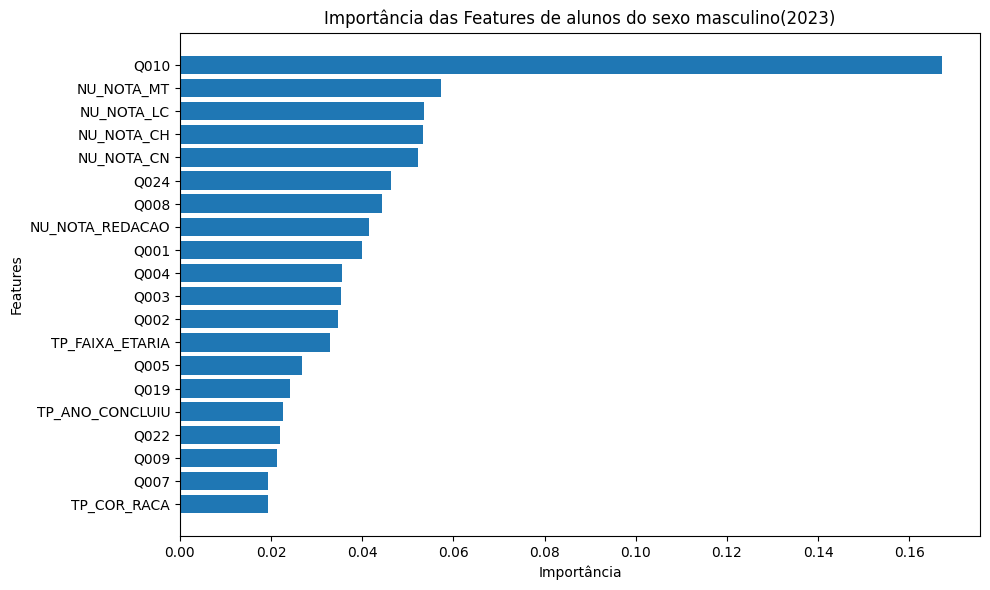

In [14]:
df_importancia_homem = analisar_importancia_features_agregada(modelo_homem, clf_homem, "de alunos do sexo masculino(2023)", 20)

Importância das features (sem agregação):
Q010_A: 0.1585
NU_NOTA_MT: 0.0572
NU_NOTA_LC: 0.0536
NU_NOTA_CH: 0.0533
NU_NOTA_CN: 0.0523
NU_NOTA_REDACAO: 0.0416
Q008_B: 0.0353
TP_FAIXA_ETARIA: 0.0328
Q024_A: 0.0292
Q005: 0.0267
TP_ANO_CONCLUIU: 0.0225
TP_COR_RACA: 0.0193
Q007_A: 0.0156
Q004_D: 0.0146
Q024_B: 0.0130
Q003_E: 0.0104
TP_ESCOLA: 0.0101
TP_ESTADO_CIVIL: 0.0088
Q014_A: 0.0087
TP_ST_CONCLUSAO: 0.0081


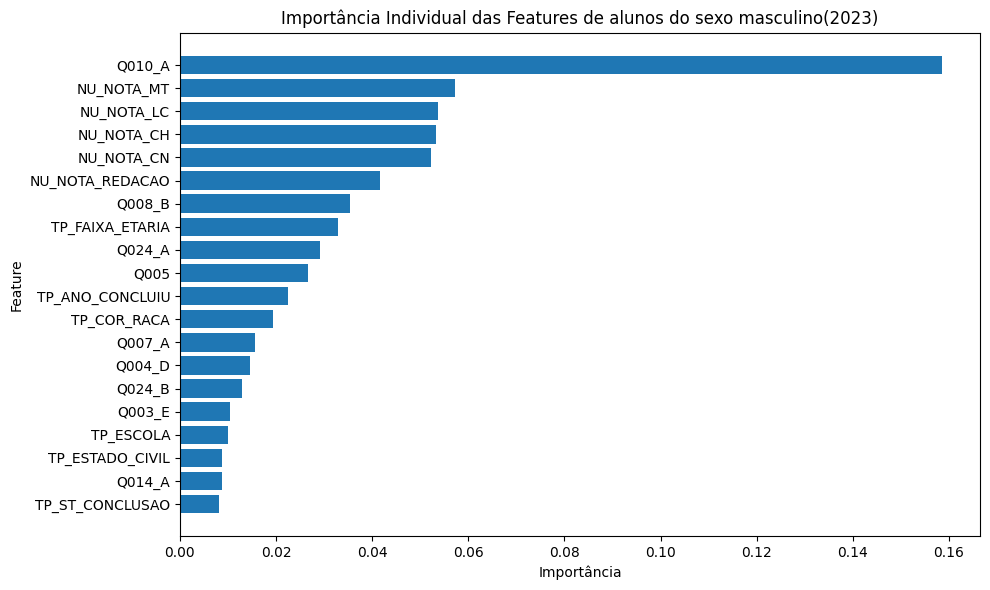

In [15]:
df_importancias_individuais_homem = analisar_importancia_features(modelo_homem, clf_homem, "de alunos do sexo masculino(2023)", top_n=20)

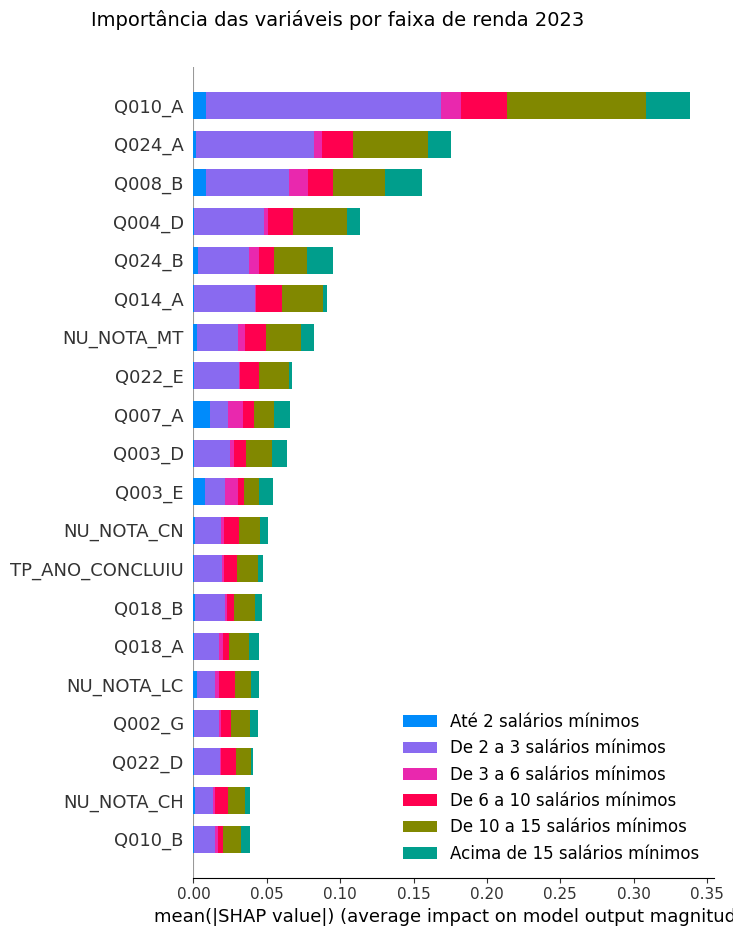

In [16]:
shap_multiclasses(df_transformado_homem, clf_homem, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


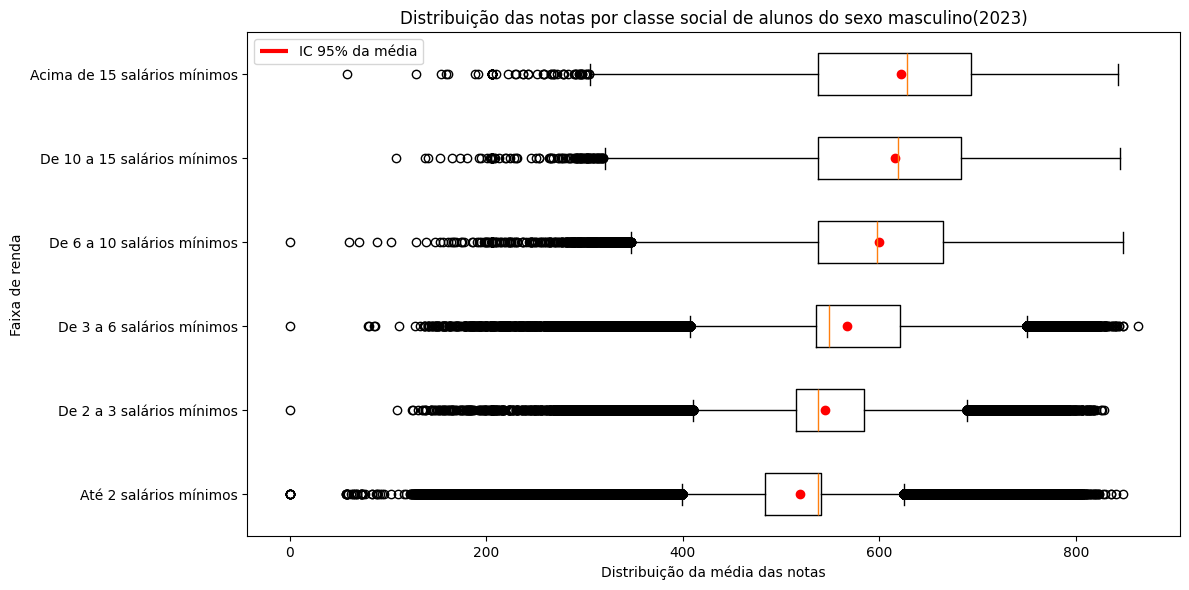

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,519.535920,537.777315,74.742969,926823,5586.511489,483.620000,540.24,0.00,847.54,847.54,14.386487,1,0.077638,519.383753,519.688086
3,De 2 a 3 salários mínimos,544.953050,537.777315,76.181452,122236,5803.613633,514.760000,584.46,0.00,827.90,827.90,13.979452,2,0.217896,544.525981,545.380119
4,De 3 a 6 salários mínimos,567.432152,548.160000,82.267139,328021,6767.882235,535.660000,621.22,0.00,862.58,862.58,14.498146,3,0.143640,567.150622,567.713681
5,De 6 a 10 salários mínimos,599.723200,597.600000,87.532071,81530,7661.863481,537.777315,664.52,0.00,847.26,847.26,14.595412,4,0.306555,599.122363,600.324037
2,De 10 a 15 salários mínimos,616.074253,619.300000,88.499522,37815,7832.165326,537.777315,682.54,107.90,844.70,736.80,14.365074,5,0.455102,615.182269,616.966237
0,Acima de 15 salários mínimos,622.174698,627.880000,91.539885,26345,8379.550553,537.777315,692.62,57.88,843.10,785.22,14.712891,6,0.563977,621.069324,623.280072


In [9]:
analisar_desempenho_por_classe(dataset_homem, "de alunos do sexo masculino(2023)")

In [18]:
modelo_mulher, clf_mulher, df_transformado_mulher = treinar_modelo(dataset_mulher)

Acurácia: 0.9998834597925916

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     25144
      Até 2 salários mínimos       1.00      1.00      1.00   1674809
 De 10 a 15 salários mínimos       1.00      1.00      1.00     41508
   De 2 a 3 salários mínimos       1.00      1.00      1.00    171758
   De 3 a 6 salários mínimos       1.00      1.00      1.00    405078
  De 6 a 10 salários mínimos       1.00      1.00      1.00     92888

                    accuracy                           1.00   2411185
                   macro avg       1.00      1.00      1.00   2411185
                weighted avg       1.00      1.00      1.00   2411185


Matriz de confusão:
 [[  25144       0       0       0       0       0]
 [      0 1674807       0       1       1       0]
 [      0       0   41508       0       0       0]
 [      0     151       0  171606       1       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1788
Feature NU_NOTA_MT: 0.0598
Feature NU_NOTA_LC: 0.0555
Feature NU_NOTA_CH: 0.0555
Feature NU_NOTA_CN: 0.0544
Feature Q008: 0.0527
Feature Q024: 0.0492
Feature NU_NOTA_REDACAO: 0.0413
Feature Q001: 0.0377
Feature Q004: 0.0366
Feature Q003: 0.0336
Feature Q002: 0.0324
Feature TP_FAIXA_ETARIA: 0.0297
Feature Q005: 0.0254
Feature Q019: 0.0224
Feature Q009: 0.0203
Feature TP_ANO_CONCLUIU: 0.0201
Feature Q022: 0.0198
Feature TP_COR_RACA: 0.0173
Feature Q007: 0.0171


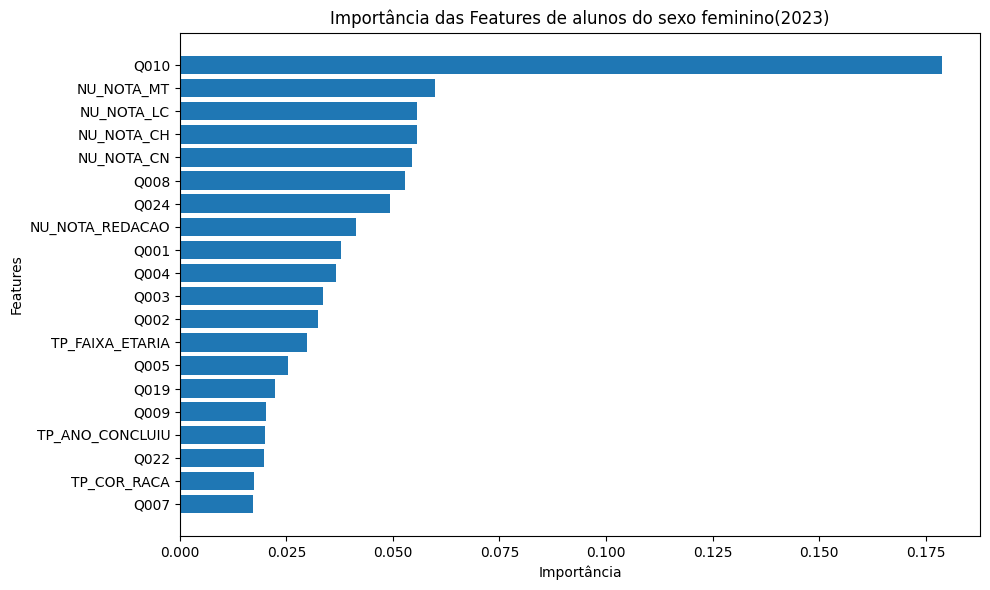

In [19]:
df_importancias_mulher = analisar_importancia_features_agregada(modelo_mulher,clf_mulher, "de alunos do sexo feminino(2023)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1707
NU_NOTA_MT: 0.0598
NU_NOTA_LC: 0.0555
NU_NOTA_CH: 0.0555
NU_NOTA_CN: 0.0544
Q008_B: 0.0446
NU_NOTA_REDACAO: 0.0413
Q024_A: 0.0330
TP_FAIXA_ETARIA: 0.0297
Q005: 0.0254
TP_ANO_CONCLUIU: 0.0201
TP_COR_RACA: 0.0173
Q004_D: 0.0172
Q007_A: 0.0138
Q024_B: 0.0126
TP_ESCOLA: 0.0097
TP_ST_CONCLUSAO: 0.0086
Q018_B: 0.0086
Q003_E: 0.0085
Q003_D: 0.0082


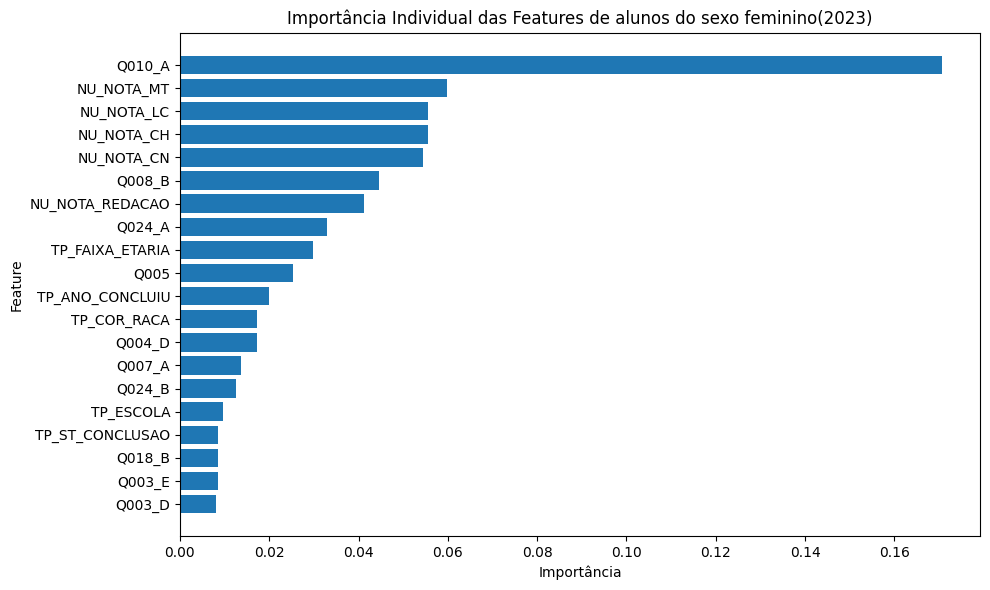

In [20]:
df_importancias_individuais_mulher = analisar_importancia_features(modelo_mulher, clf_mulher, "de alunos do sexo feminino(2023)", top_n=20)

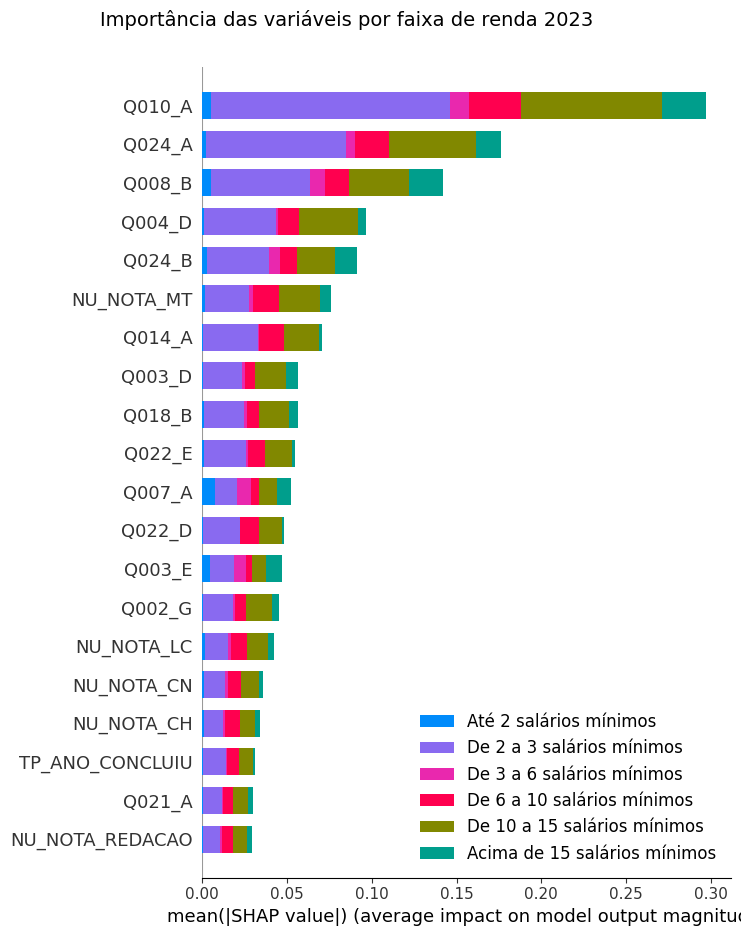

In [21]:
shap_multiclasses(df_transformado_mulher, clf_mulher, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


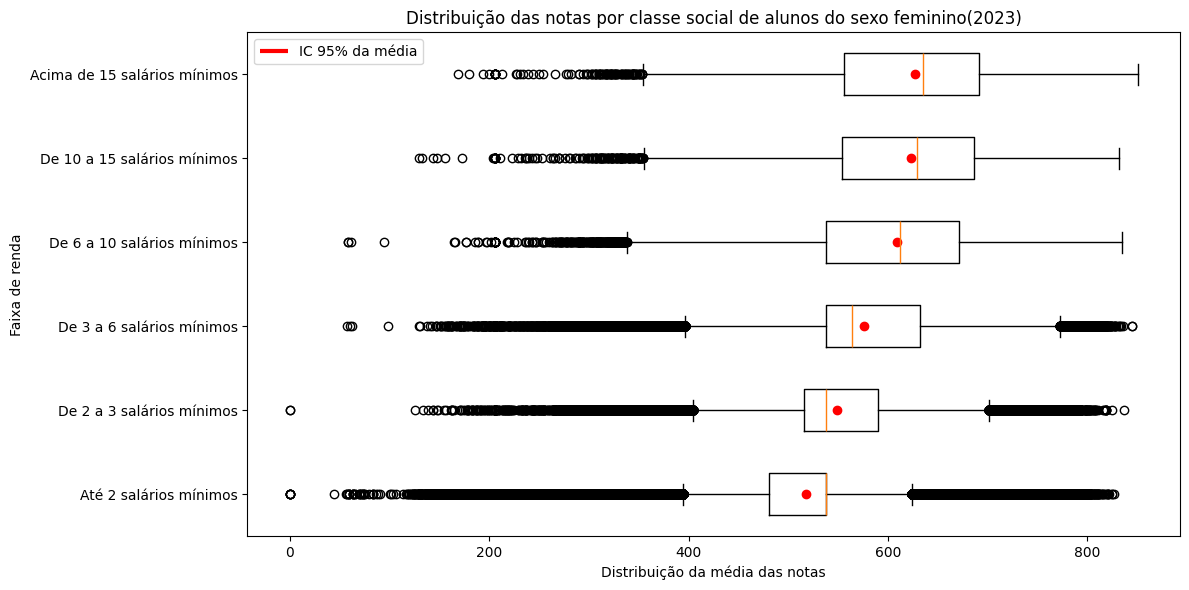

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,517.474914,537.777315,69.073532,1674809,4771.152881,480.480000,537.777315,0.00,826.30,826.30,13.348190,1,0.053374,517.370303,517.579525
3,De 2 a 3 salários mínimos,549.341013,537.777315,73.088889,171758,5341.985755,515.940000,590.100000,0.00,836.80,836.80,13.304830,2,0.176357,548.995359,549.686666
4,De 3 a 6 salários mínimos,576.299796,564.240000,79.789635,405078,6366.385927,537.777315,631.780000,57.76,844.52,786.76,13.845161,3,0.125365,576.054085,576.545507
5,De 6 a 10 salários mínimos,609.564911,611.740000,82.536071,92888,6812.203069,537.777315,670.925000,58.52,834.50,775.98,13.540161,4,0.270810,609.034134,610.095688
2,De 10 a 15 salários mínimos,623.482804,629.340000,82.699978,41508,6839.286306,553.560000,686.180000,130.18,831.62,701.44,13.264195,5,0.405919,622.687217,624.278390
0,Acima de 15 salários mínimos,627.401543,635.260000,83.825011,25144,7026.632447,556.155000,690.960000,168.40,850.40,682.00,13.360664,6,0.528636,626.365436,628.437650


In [10]:
analisar_desempenho_por_classe(dataset_mulher, "de alunos do sexo feminino(2023)")

In [11]:
# Filtrar apenas escolas urbanas
dataset_urbano = dataset_sem_nulos[dataset_sem_nulos['TP_LOCALIZACAO_ESC'] == 1]
num_columns = dataset_urbano.shape[1]
num_rows = dataset_urbano.shape[0]
print(f"Número de colunas dataset urbano: {num_columns}")
print(f"Número de linhas dataset urbano: {num_rows}")

# Filtrar apenas escolas rurais
dataset_rural = dataset_sem_nulos[dataset_sem_nulos['TP_LOCALIZACAO_ESC'] == 2]
num_columns = dataset_rural.shape[1]
num_rows = dataset_rural.shape[0]
print(f"Número de colunas dataset rural: {num_columns}")
print(f"Número de linhas dataset rural: {num_rows}")

Número de colunas dataset urbano: 41
Número de linhas dataset urbano: 3898305
Número de colunas dataset rural: 41
Número de linhas dataset rural: 35650


In [24]:
modelo_urbano, clf_urbano, df_transformado_urbano = treinar_modelo(dataset_urbano)

Acurácia: 0.9998904652150101

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     51421
      Até 2 salários mínimos       1.00      1.00      1.00   2572953
 De 10 a 15 salários mínimos       1.00      1.00      1.00     79174
   De 2 a 3 salários mínimos       1.00      1.00      1.00    291943
   De 3 a 6 salários mínimos       1.00      1.00      1.00    728953
  De 6 a 10 salários mínimos       1.00      1.00      1.00    173861

                    accuracy                           1.00   3898305
                   macro avg       1.00      1.00      1.00   3898305
                weighted avg       1.00      1.00      1.00   3898305


Matriz de confusão:
 [[  51421       0       0       0       0       0]
 [      0 2572949       0       1       3       0]
 [      0       0   79174       0       0       0]
 [      0     219       0  291723       1       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1752
Feature NU_NOTA_MT: 0.0593
Feature NU_NOTA_LC: 0.0548
Feature NU_NOTA_CH: 0.0544
Feature NU_NOTA_CN: 0.0537
Feature Q008: 0.0484
Feature Q024: 0.0483
Feature NU_NOTA_REDACAO: 0.0413
Feature Q001: 0.0368
Feature Q004: 0.0349
Feature Q003: 0.0334
Feature Q002: 0.0323
Feature TP_FAIXA_ETARIA: 0.0303
Feature Q005: 0.0257
Feature Q019: 0.0222
Feature TP_ANO_CONCLUIU: 0.0206
Feature Q009: 0.0202
Feature Q022: 0.0197
Feature TP_COR_RACA: 0.0179
Feature Q007: 0.0178


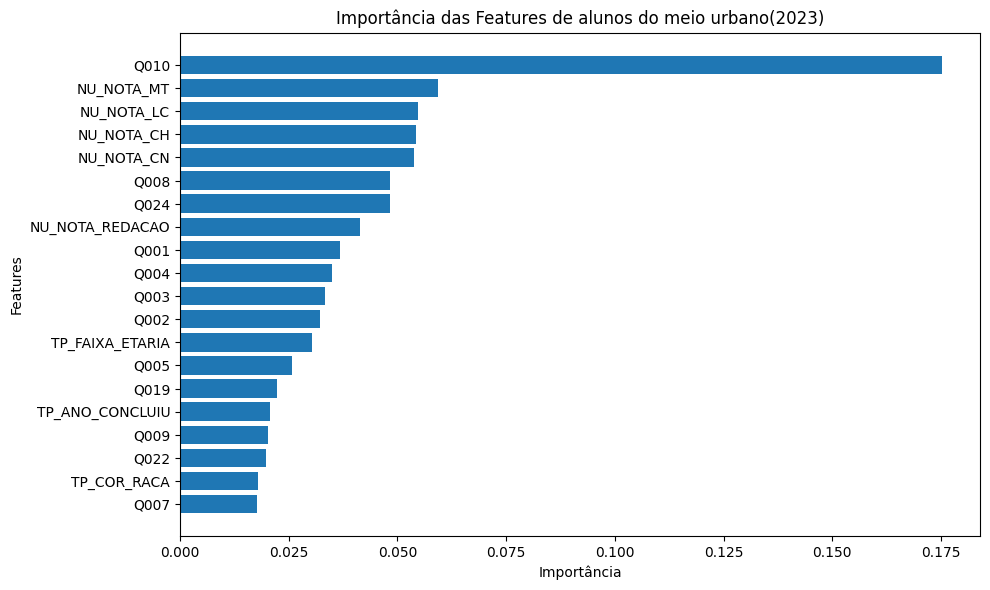

In [25]:
df_importancia_urbano = analisar_importancia_features_agregada(modelo_urbano, clf_urbano, "de alunos do meio urbano(2023)", 20)

Importância das features (sem agregação):
Q010_A: 0.1673
NU_NOTA_MT: 0.0593
NU_NOTA_LC: 0.0548
NU_NOTA_CH: 0.0544
NU_NOTA_CN: 0.0537
NU_NOTA_REDACAO: 0.0413
Q008_B: 0.0403
Q024_A: 0.0320
TP_FAIXA_ETARIA: 0.0303
Q005: 0.0257
TP_ANO_CONCLUIU: 0.0206
TP_COR_RACA: 0.0179
Q004_D: 0.0156
Q007_A: 0.0144
Q024_B: 0.0128
TP_ESCOLA: 0.0096
Q003_E: 0.0092
Q014_A: 0.0085
TP_ST_CONCLUSAO: 0.0083
Q003_D: 0.0079


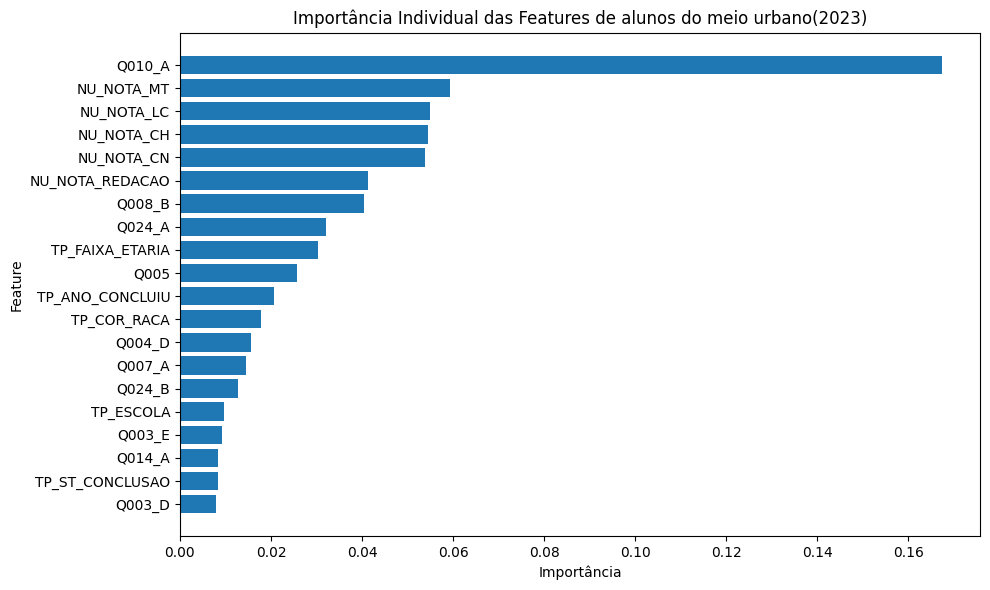

In [26]:
df_importancias_individuais_urbano = analisar_importancia_features(modelo_urbano, clf_urbano, "de alunos do meio urbano(2023)", top_n=20)

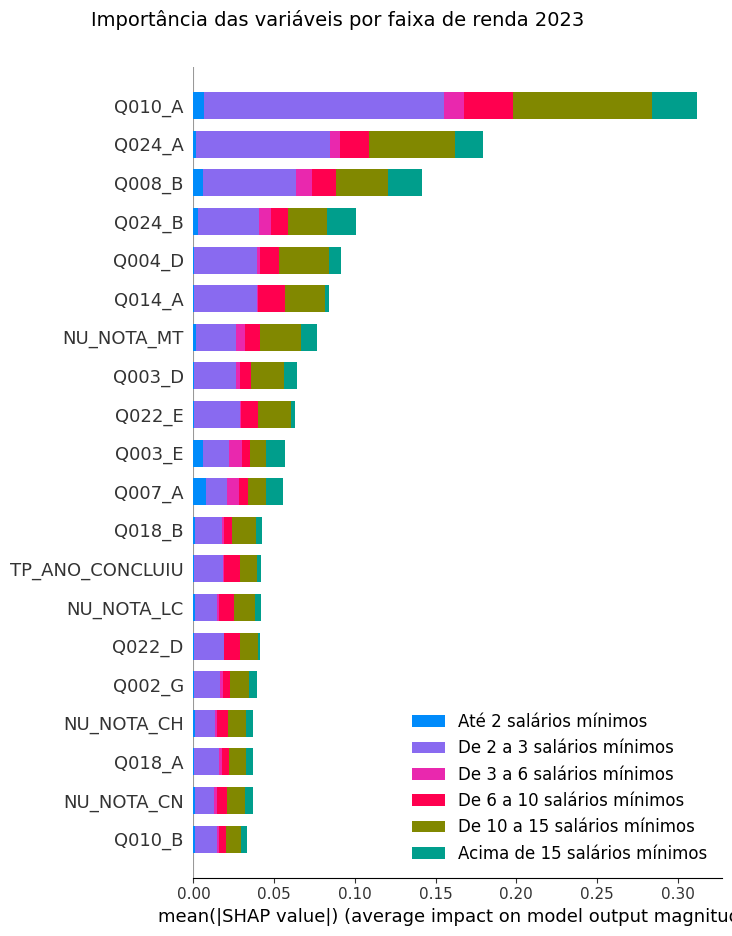

In [27]:
shap_multiclasses(df_transformado_urbano, clf_urbano, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


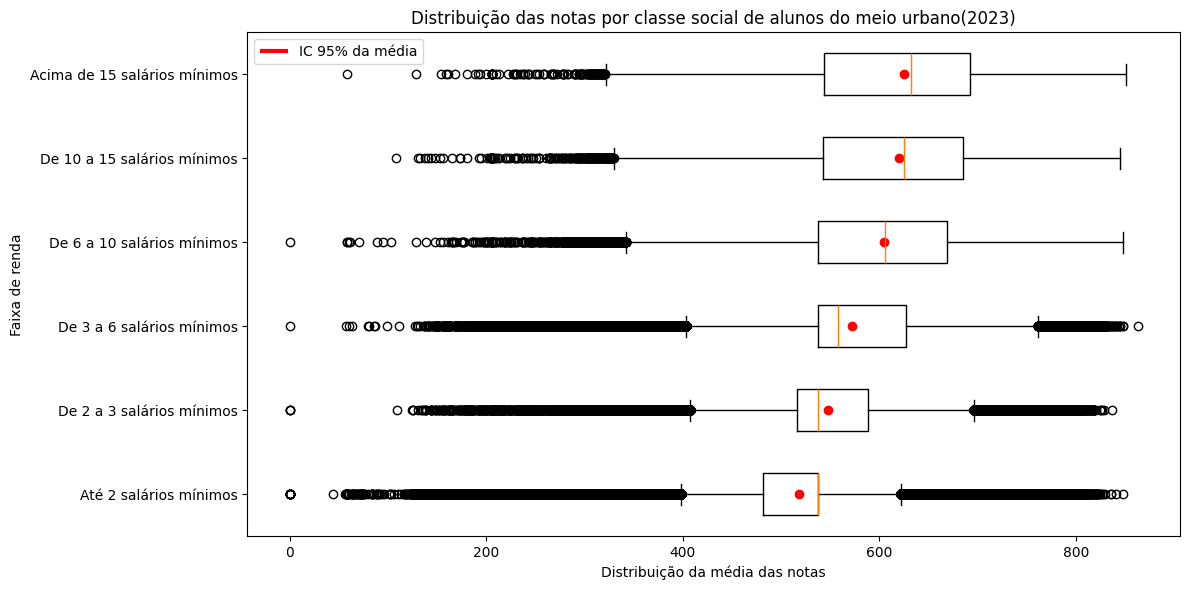

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,518.383721,537.777315,71.046949,2572953,5047.668953,481.780000,537.777315,0.00,847.54,847.54,13.705475,1,0.044292,518.296909,518.470533
3,De 2 a 3 salários mínimos,547.609059,537.777315,74.391194,291943,5534.049726,515.660000,587.900000,0.00,836.80,836.80,13.584727,2,0.137681,547.339210,547.878908
4,De 3 a 6 salários mínimos,572.406316,557.400000,81.021302,728953,6564.451392,537.777315,627.340000,0.00,862.58,862.58,14.154509,3,0.094896,572.220323,572.592309
5,De 6 a 10 salários mínimos,605.017668,605.460000,85.060937,173861,7235.362978,537.777315,668.200000,0.00,847.26,847.26,14.059248,4,0.203999,604.617837,605.417500
2,De 10 a 15 salários mínimos,620.008815,624.920000,85.591235,79174,7325.859558,542.660000,684.560000,107.90,844.70,736.80,13.804842,5,0.304185,619.412623,620.605007
0,Acima de 15 salários mínimos,624.830056,631.980000,87.856635,51421,7718.788346,543.499865,691.740000,57.88,850.40,792.52,14.060885,6,0.387440,624.070688,625.589424


In [12]:
analisar_desempenho_por_classe(dataset_urbano, "de alunos do meio urbano(2023)")

In [13]:
# Filtrar apenas homens do meio urbano
dataset_urbano_homem = dataset_urbano[dataset_urbano['TP_SEXO'] == "M"]
num_columns = dataset_urbano_homem.shape[1]
num_rows = dataset_urbano_homem.shape[0]
print(f"Número de colunas dataset urbano homem: {num_columns}")
print(f"Número de linhas dataset urbano homem: {num_rows}")

# Filtrar apenas mulheres do meio urbano
dataset_urbano_mulher = dataset_urbano[dataset_urbano['TP_SEXO'] == "F"]
num_columns = dataset_urbano_mulher.shape[1]
num_rows = dataset_urbano_mulher.shape[0]
print(f"Número de colunas dataset urbano mulher: {num_columns}")
print(f"Número de linhas dataset urbano mulher: {num_rows}")

Número de colunas dataset urbano homem: 41
Número de linhas dataset urbano homem: 1506672
Número de colunas dataset urbano mulher: 41
Número de linhas dataset urbano mulher: 2391633


In [30]:
modelo_urbano_homem, clf_urbano_homem, df_transformado_urbano_homem = treinar_modelo(dataset_urbano_homem)

Acurácia: 0.9999030976881498

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     26299
      Até 2 salários mínimos       1.00      1.00      1.00    914343
 De 10 a 15 salários mínimos       1.00      1.00      1.00     37735
   De 2 a 3 salários mínimos       1.00      1.00      1.00    121209
   De 3 a 6 salários mínimos       1.00      1.00      1.00    325842
  De 6 a 10 salários mínimos       1.00      1.00      1.00     81244

                    accuracy                           1.00   1506672
                   macro avg       1.00      1.00      1.00   1506672
                weighted avg       1.00      1.00      1.00   1506672


Matriz de confusão:
 [[ 26299      0      0      0      0      0]
 [     0 914341      0      0      2      0]
 [     0      0  37735      0      0      0]
 [     0     68      0 121141      0      0]
 [     0     60      1     12 325769

Importância das features (agregada):
Feature Q010: 0.1669
Feature NU_NOTA_MT: 0.0574
Feature NU_NOTA_LC: 0.0538
Feature NU_NOTA_CH: 0.0535
Feature NU_NOTA_CN: 0.0529
Feature Q024: 0.0460
Feature Q008: 0.0443
Feature NU_NOTA_REDACAO: 0.0411
Feature Q001: 0.0401
Feature Q003: 0.0355
Feature Q004: 0.0351
Feature Q002: 0.0344
Feature TP_FAIXA_ETARIA: 0.0329
Feature Q005: 0.0264
Feature Q019: 0.0243
Feature TP_ANO_CONCLUIU: 0.0228
Feature Q022: 0.0220
Feature Q009: 0.0216
Feature TP_COR_RACA: 0.0194
Feature Q007: 0.0193


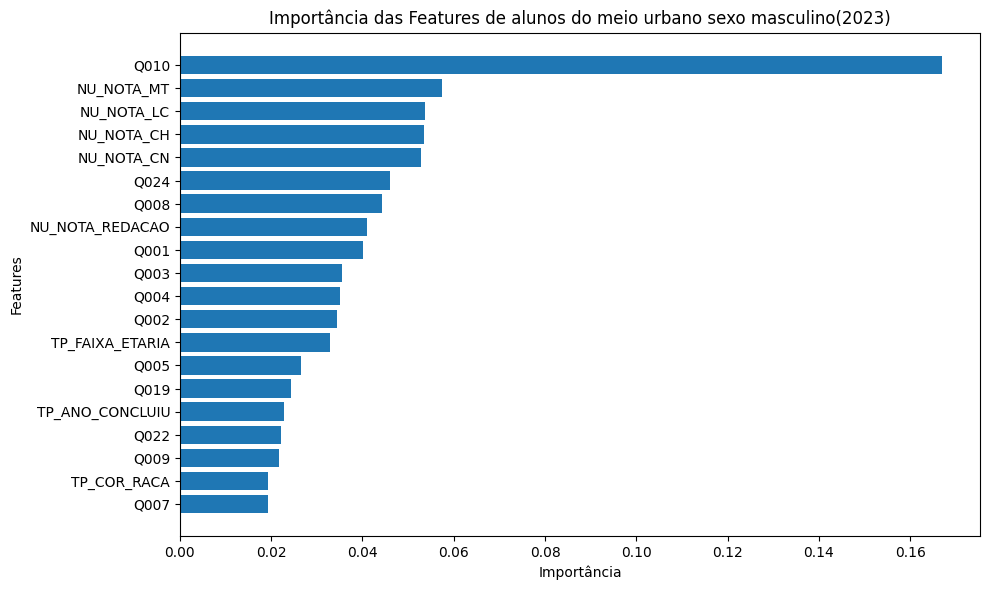

In [31]:
df_importancia_urbano_homem = analisar_importancia_features_agregada(modelo_urbano_homem, clf_urbano_homem, "de alunos do meio urbano sexo masculino(2023)", 20)

Importância das features (sem agregação):
Q010_A: 0.1583
NU_NOTA_MT: 0.0574
NU_NOTA_LC: 0.0538
NU_NOTA_CH: 0.0535
NU_NOTA_CN: 0.0529
NU_NOTA_REDACAO: 0.0411
Q008_B: 0.0352
TP_FAIXA_ETARIA: 0.0329
Q024_A: 0.0289
Q005: 0.0264
TP_ANO_CONCLUIU: 0.0228
TP_COR_RACA: 0.0194
Q007_A: 0.0157
Q004_D: 0.0144
Q024_B: 0.0130
Q003_E: 0.0104
TP_ESCOLA: 0.0101
TP_ESTADO_CIVIL: 0.0088
Q014_A: 0.0088
TP_ST_CONCLUSAO: 0.0084


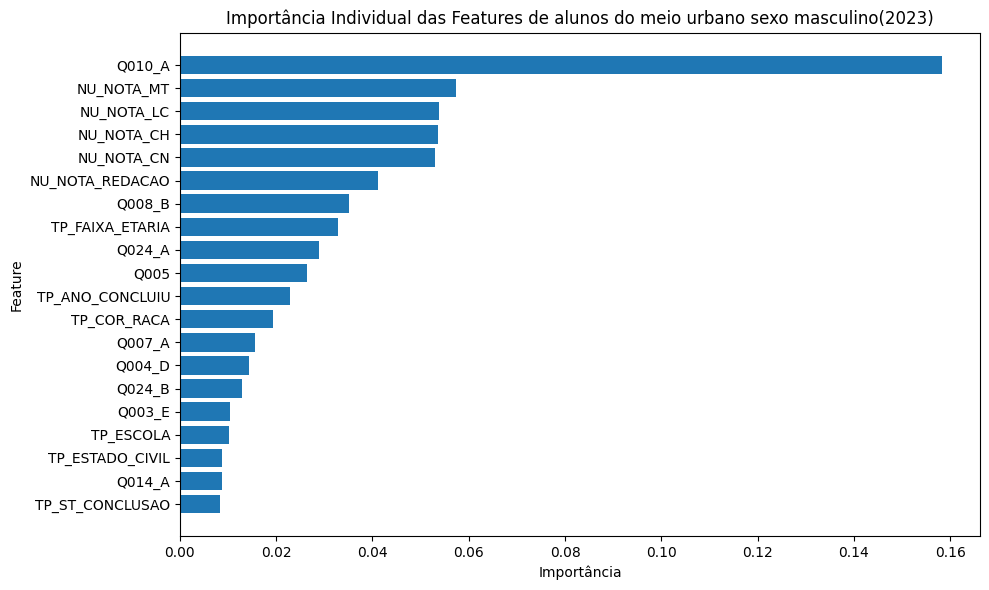

In [32]:
df_importancias_individuais_urbano_homem = analisar_importancia_features(modelo_urbano_homem, clf_urbano_homem, "de alunos do meio urbano sexo masculino(2023)", top_n=20)

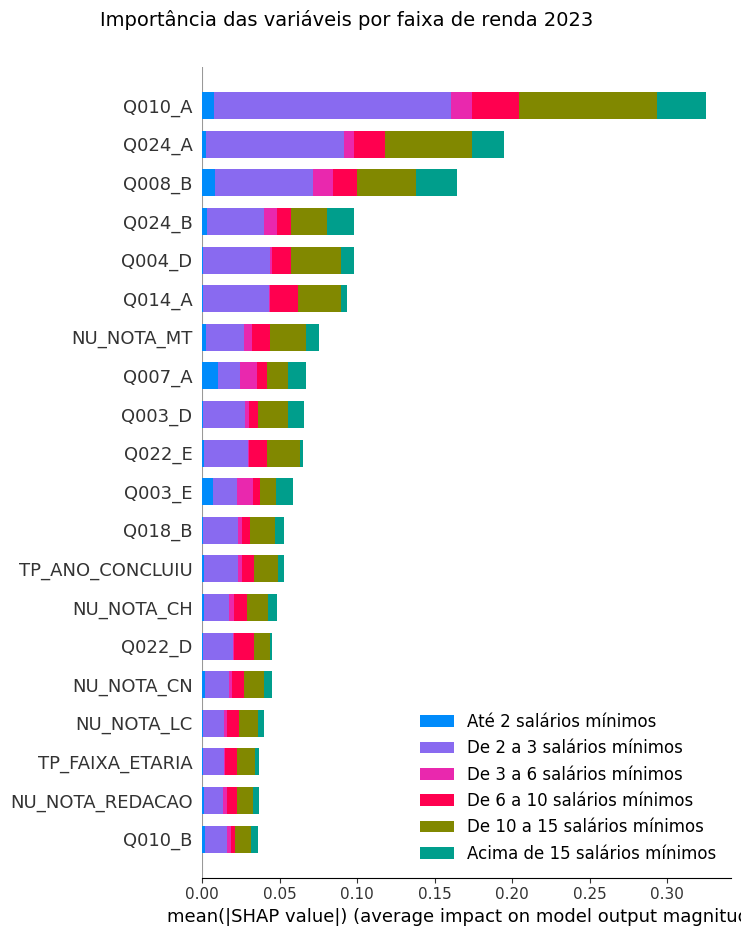

In [33]:
shap_multiclasses(df_transformado_urbano_homem, clf_urbano_homem, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


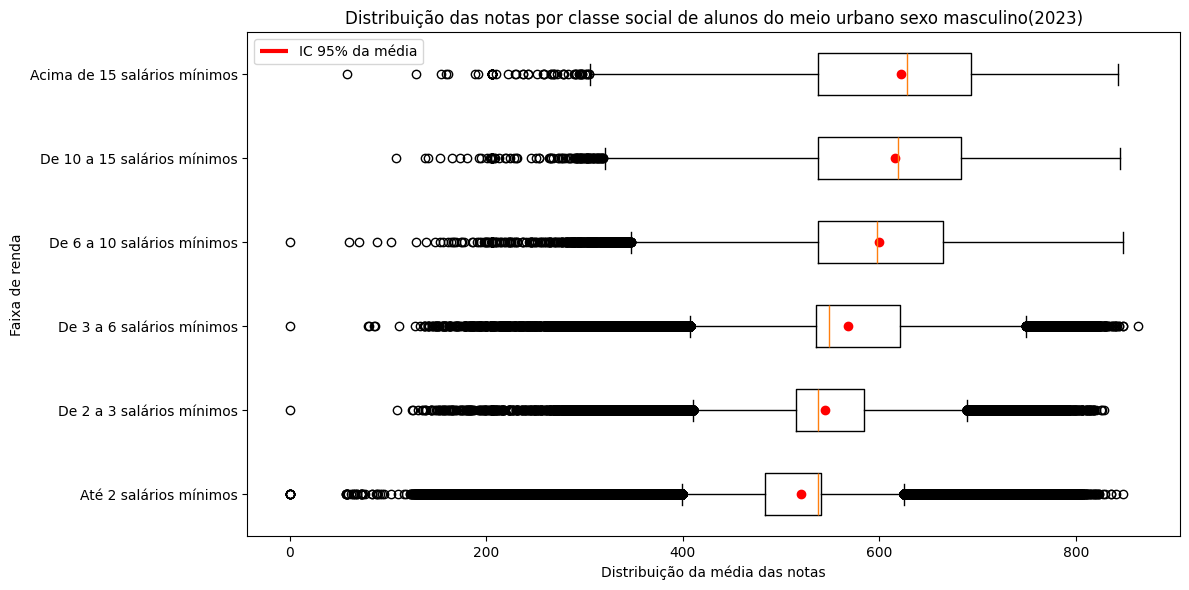

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,519.785099,537.777315,74.598396,914343,5564.920727,483.980000,540.52,0.00,847.54,847.54,14.351777,1,0.078014,519.632193,519.938004
3,De 2 a 3 salários mínimos,545.076431,537.777315,76.139388,121209,5797.206394,515.020000,584.60,0.00,827.90,827.90,13.968571,2,0.218697,544.647794,545.505068
4,De 3 a 6 salários mínimos,567.526235,548.200000,82.256428,325842,6766.119963,535.838053,621.30,0.00,862.58,862.58,14.493855,3,0.144101,567.243803,567.808667
5,De 6 a 10 salários mínimos,599.787873,597.660000,87.552308,81244,7665.406712,537.777315,664.62,0.00,847.26,847.26,14.597212,4,0.307165,599.185840,600.389906
2,De 10 a 15 salários mínimos,616.132539,619.340000,88.499888,37735,7832.230119,537.777315,682.59,107.90,844.70,736.80,14.363774,5,0.455586,615.239606,617.025471
0,Acima de 15 salários mínimos,622.317884,628.060000,91.507635,26299,8373.647306,537.777315,692.74,57.88,843.10,785.22,14.704324,6,0.564271,621.211933,623.423835


In [14]:
analisar_desempenho_por_classe(dataset_urbano_homem, "de alunos do meio urbano sexo masculino(2023)")

In [35]:
modelo_urbano_mulher, clf_urbano_mulher, df_transformado_urbano_mulher = treinar_modelo(dataset_urbano_mulher)

Acurácia: 0.9998825070568937

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     25122
      Até 2 salários mínimos       1.00      1.00      1.00   1658610
 De 10 a 15 salários mínimos       1.00      1.00      1.00     41439
   De 2 a 3 salários mínimos       1.00      1.00      1.00    170734
   De 3 a 6 salários mínimos       1.00      1.00      1.00    403111
  De 6 a 10 salários mínimos       1.00      1.00      1.00     92617

                    accuracy                           1.00   2391633
                   macro avg       1.00      1.00      1.00   2391633
                weighted avg       1.00      1.00      1.00   2391633


Matriz de confusão:
 [[  25122       0       0       0       0       0]
 [      0 1658608       0       1       1       0]
 [      0       0   41439       0       0       0]
 [      0     151       0  170582       1       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1791
Feature NU_NOTA_MT: 0.0599
Feature NU_NOTA_LC: 0.0557
Feature NU_NOTA_CH: 0.0554
Feature NU_NOTA_CN: 0.0546
Feature Q008: 0.0523
Feature Q024: 0.0490
Feature NU_NOTA_REDACAO: 0.0413
Feature Q001: 0.0375
Feature Q004: 0.0367
Feature Q003: 0.0333
Feature Q002: 0.0326
Feature TP_FAIXA_ETARIA: 0.0301
Feature Q005: 0.0256
Feature Q019: 0.0228
Feature TP_ANO_CONCLUIU: 0.0203
Feature Q009: 0.0203
Feature Q022: 0.0199
Feature TP_COR_RACA: 0.0173
Feature Q007: 0.0170


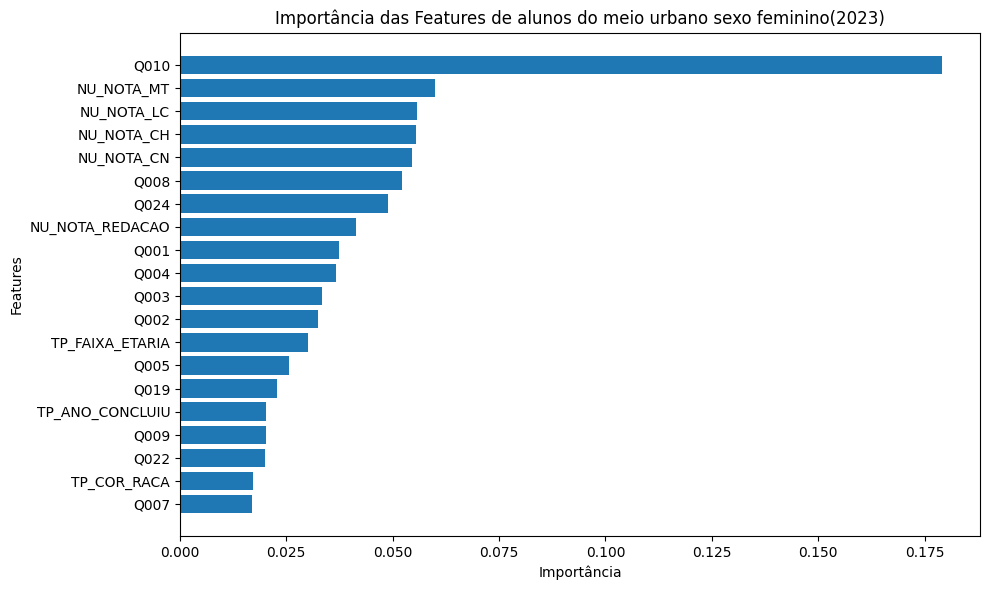

In [36]:
df_importancia_urbano_mulher = analisar_importancia_features_agregada(modelo_urbano_mulher, clf_urbano_mulher, "de alunos do meio urbano sexo feminino(2023)", 20)

Importância das features (sem agregação):
Q010_A: 0.1708
NU_NOTA_MT: 0.0599
NU_NOTA_LC: 0.0557
NU_NOTA_CH: 0.0554
NU_NOTA_CN: 0.0546
Q008_B: 0.0444
NU_NOTA_REDACAO: 0.0413
Q024_A: 0.0328
TP_FAIXA_ETARIA: 0.0301
Q005: 0.0256
TP_ANO_CONCLUIU: 0.0203
TP_COR_RACA: 0.0173
Q004_D: 0.0171
Q007_A: 0.0138
Q024_B: 0.0126
TP_ESCOLA: 0.0097
TP_ST_CONCLUSAO: 0.0086
Q003_E: 0.0085
Q003_D: 0.0082
Q001_E: 0.0078


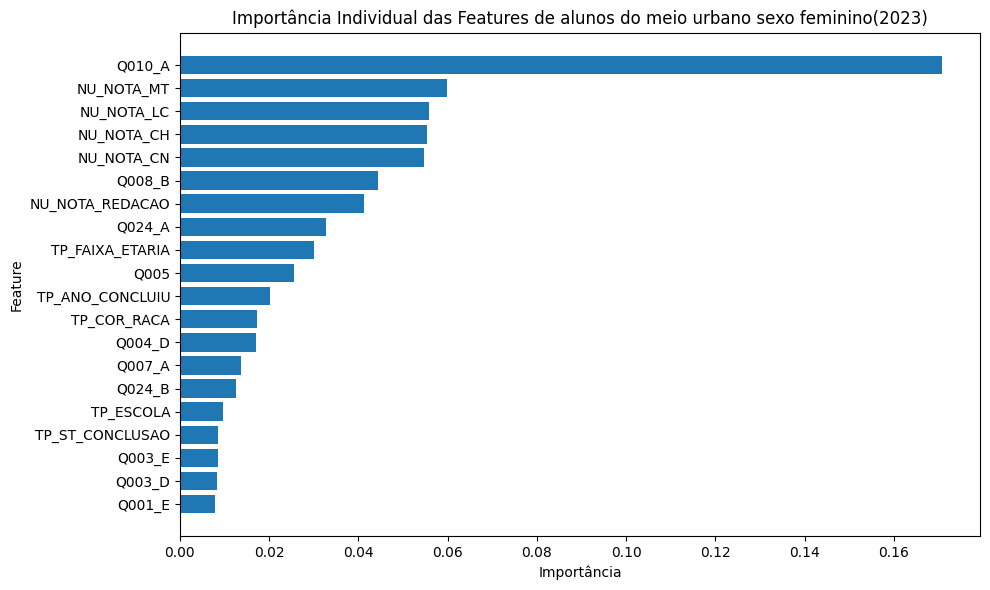

In [37]:
df_importancias_individuais_urbano_mulher = analisar_importancia_features(modelo_urbano_mulher, clf_urbano_mulher, "de alunos do meio urbano sexo feminino(2023)", top_n=20)

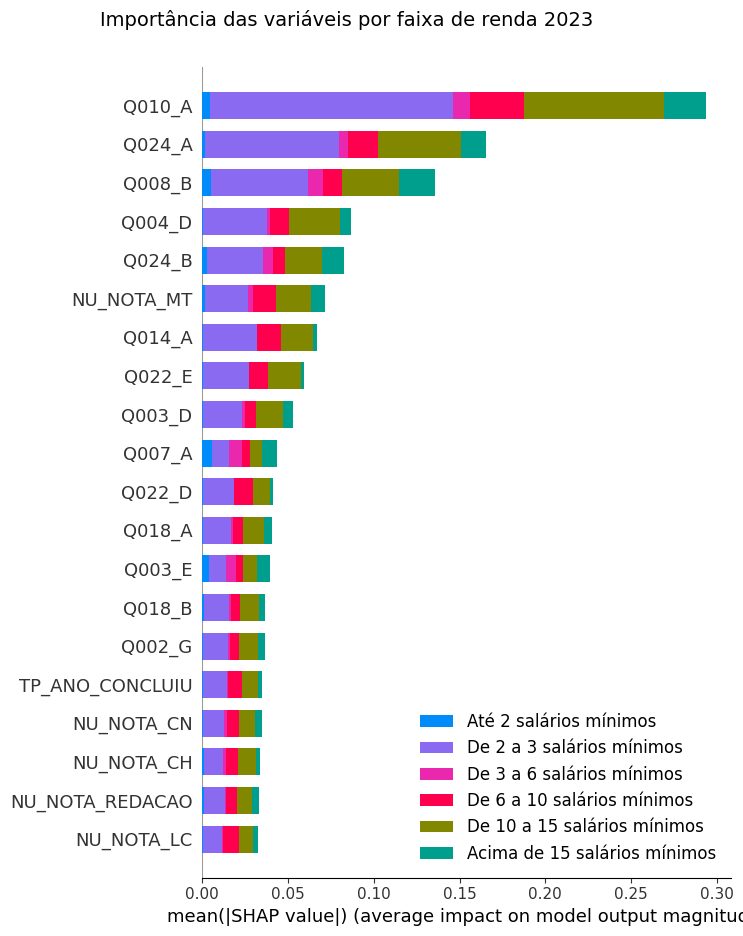

In [38]:
shap_multiclasses(df_transformado_urbano_mulher, clf_urbano_mulher, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


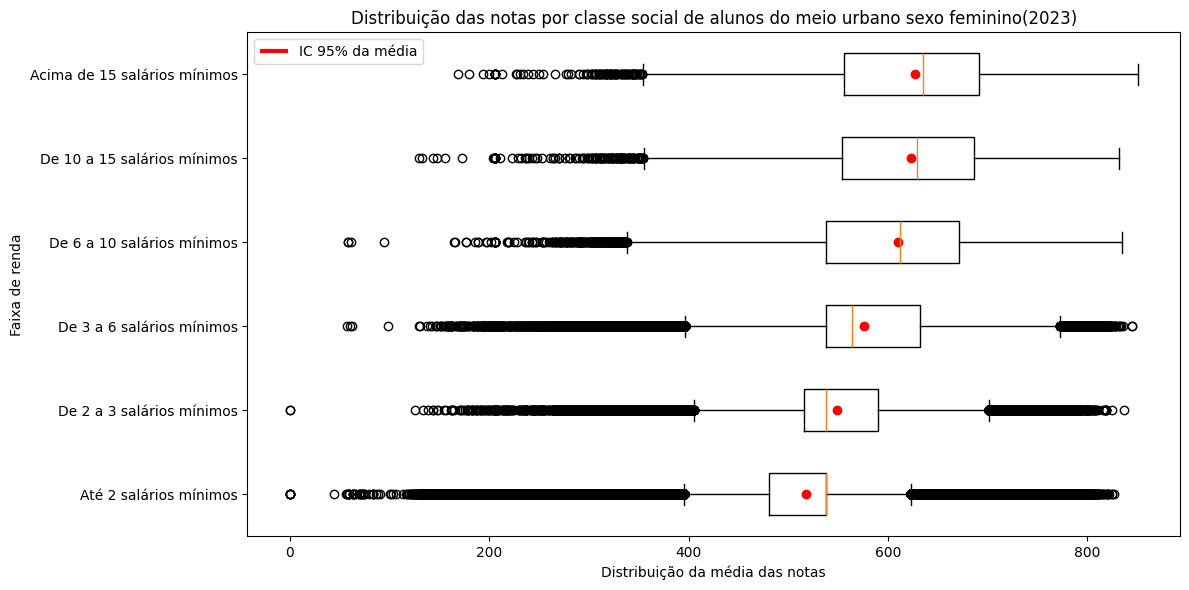

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,517.611183,537.777315,68.998891,1658610,4760.846984,480.704362,537.777315,0.00,826.30,826.30,13.330255,1,0.053576,517.506176,517.716190
3,De 2 a 3 salários mínimos,549.407045,537.777315,73.071702,170734,5339.473637,516.120000,590.120000,0.00,836.80,836.80,13.300103,2,0.176844,549.060438,549.753652
4,De 3 a 6 salários mínimos,576.350975,564.260000,79.791257,403111,6366.644702,537.777315,631.820000,57.76,844.52,786.76,13.844213,3,0.125673,576.104660,576.597290
5,De 6 a 10 salários mínimos,609.605266,611.760000,82.541910,92617,6813.166869,537.777315,671.000000,58.52,834.50,775.98,13.540223,4,0.271225,609.073675,610.136856
2,De 10 a 15 salários mínimos,623.538612,629.417450,82.696952,41439,6838.785935,553.588725,686.220000,130.18,831.62,701.44,13.262523,5,0.406242,622.742393,624.334832
0,Acima de 15 salários mínimos,627.459926,635.300000,83.785625,25122,7020.030950,556.225000,690.975000,168.40,850.40,682.00,13.353144,6,0.528619,626.423853,628.496000


In [15]:
analisar_desempenho_por_classe(dataset_urbano_mulher, "de alunos do meio urbano sexo feminino(2023)")

In [40]:
modelo_rural, clf_rural, df_transformado_rural = treinar_modelo(dataset_rural)

Acurácia: 1.0

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        68
      Até 2 salários mínimos       1.00      1.00      1.00     28679
 De 10 a 15 salários mínimos       1.00      1.00      1.00       149
   De 2 a 3 salários mínimos       1.00      1.00      1.00      2051
   De 3 a 6 salários mínimos       1.00      1.00      1.00      4146
  De 6 a 10 salários mínimos       1.00      1.00      1.00       557

                    accuracy                           1.00     35650
                   macro avg       1.00      1.00      1.00     35650
                weighted avg       1.00      1.00      1.00     35650


Matriz de confusão:
 [[   68     0     0     0     0     0]
 [    0 28679     0     0     0     0]
 [    0     0   149     0     0     0]
 [    0     0     0  2051     0     0]
 [    0     0     0     0  4146     0]
 [    0     0     0     0     0   55

Importância das features (agregada):
Feature Q010: 0.1672
Feature Q024: 0.0719
Feature Q004: 0.0594
Feature NU_NOTA_MT: 0.0573
Feature NU_NOTA_LC: 0.0565
Feature NU_NOTA_CH: 0.0563
Feature NU_NOTA_CN: 0.0478
Feature NU_NOTA_REDACAO: 0.0428
Feature Q001: 0.0414
Feature Q003: 0.0393
Feature Q002: 0.0361
Feature Q022: 0.0286
Feature Q005: 0.0276
Feature Q008: 0.0244
Feature Q009: 0.0211
Feature Q011: 0.0208
Feature TP_FAIXA_ETARIA: 0.0204
Feature TP_COR_RACA: 0.0189
Feature Q019: 0.0187
Feature Q014: 0.0170


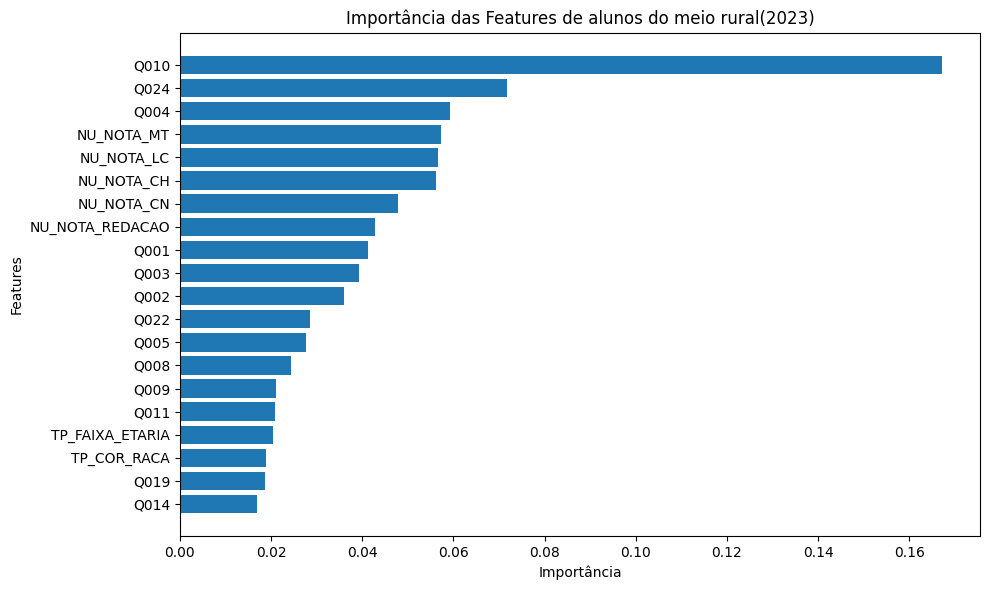

In [41]:
df_importancia_rural = analisar_importancia_features_agregada(modelo_rural,clf_rural, "de alunos do meio rural(2023)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1582
Q024_A: 0.0609
NU_NOTA_MT: 0.0573
NU_NOTA_LC: 0.0565
NU_NOTA_CH: 0.0563
NU_NOTA_CN: 0.0478
NU_NOTA_REDACAO: 0.0428
Q004_D: 0.0367
Q005: 0.0276
TP_FAIXA_ETARIA: 0.0204
TP_COR_RACA: 0.0189
Q008_B: 0.0166
Q014_A: 0.0123
Q003_D: 0.0108
Q021_B: 0.0094
Q022_E: 0.0089
Q002_G: 0.0087
Q001_E: 0.0085
Q009_C: 0.0084
Q004_E: 0.0084


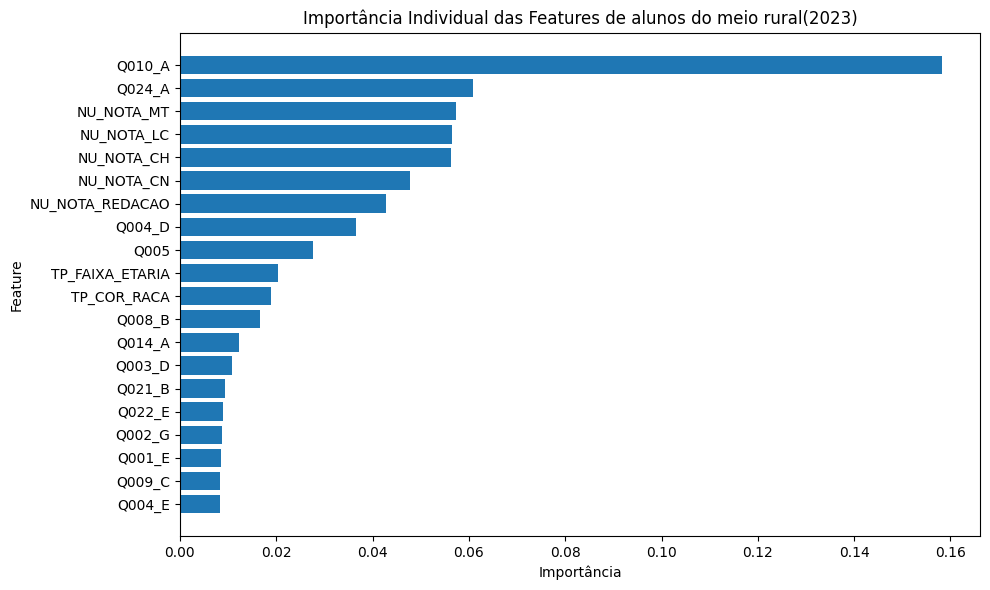

In [42]:
df_importancias_individuais_rural = analisar_importancia_features(modelo_rural, clf_rural, "de alunos do meio rural(2023)", top_n=20)

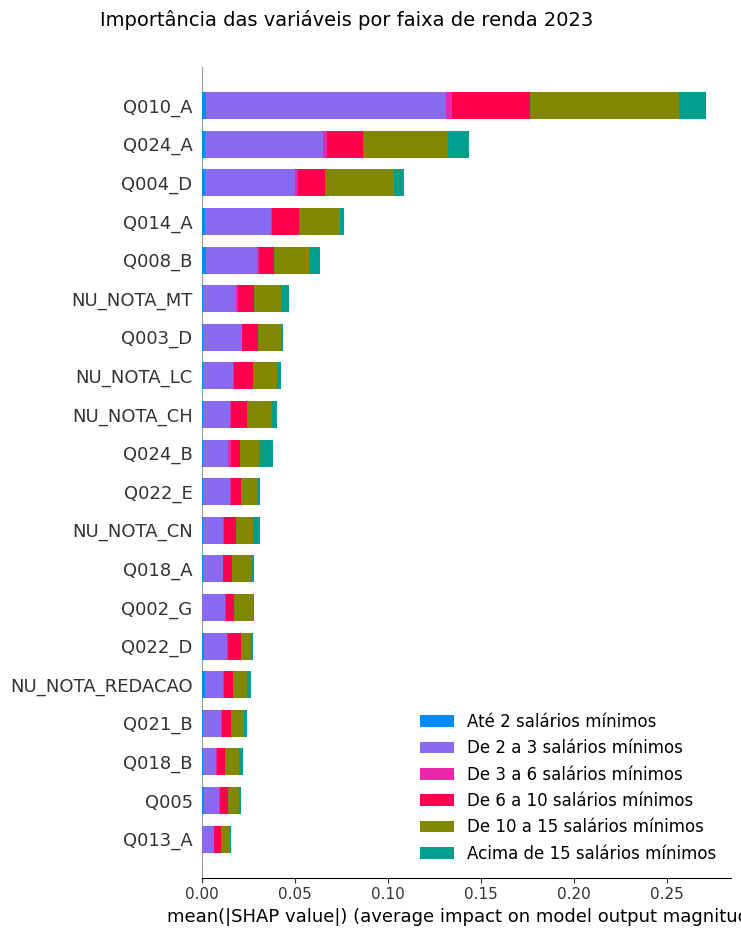

In [43]:
shap_multiclasses(df_transformado_rural, clf_rural, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


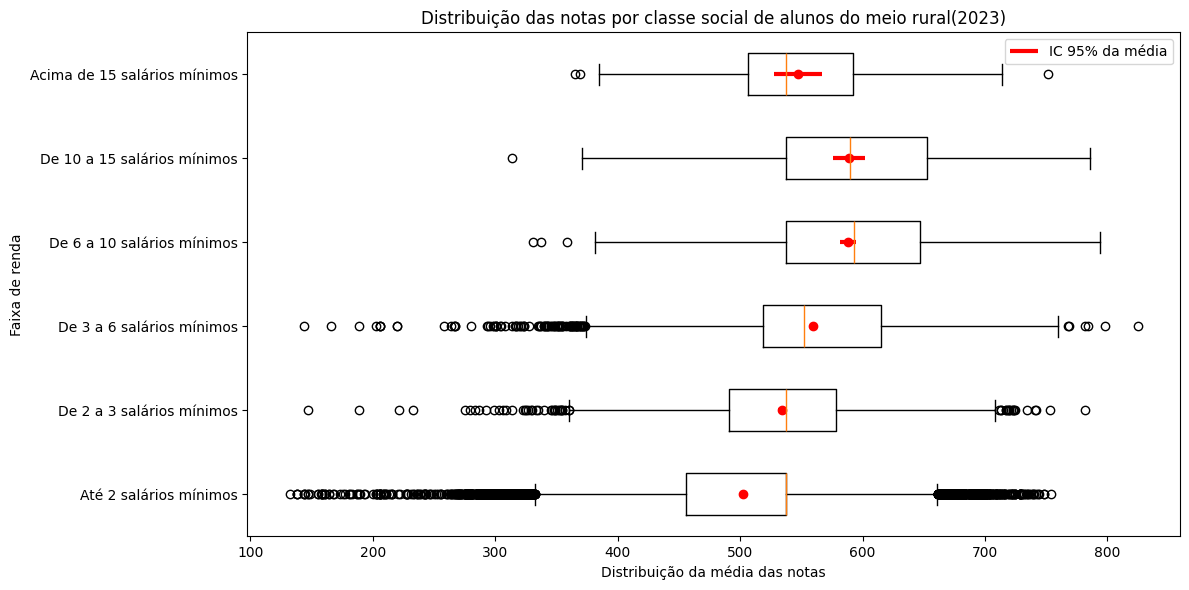

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,502.546582,537.777315,78.445877,28679,6153.755632,455.560000,537.777315,132.00000,753.90,621.90000,15.609673,1,0.463221,501.638686,503.454479
3,De 2 a 3 salários mínimos,534.355512,537.777315,77.534757,2051,6011.638511,491.260000,578.550000,147.18000,781.42,634.24000,14.509957,2,1.712039,530.999977,537.711046
4,De 3 a 6 salários mínimos,559.269009,551.870000,81.078927,4146,6573.792393,518.510000,615.110000,143.70000,824.62,680.92000,14.497304,3,1.259196,556.801030,561.736988
5,De 6 a 10 salários mínimos,588.368252,592.980000,79.800210,557,6368.073533,537.777315,646.980000,330.46000,794.14,463.68000,13.562970,4,3.381243,581.741136,594.995367
2,De 10 a 15 salários mínimos,589.222748,589.840000,81.315495,149,6612.209791,537.777315,652.580000,313.30000,785.90,472.60000,13.800468,5,6.661625,576.166203,602.279292
0,Acima de 15 salários mínimos,546.919173,537.777315,82.918582,68,6875.491272,506.325000,591.965000,364.73745,751.44,386.70255,15.161030,6,10.055355,527.211039,566.627306


In [16]:
analisar_desempenho_por_classe(dataset_rural, "de alunos do meio rural(2023)")

In [17]:
# Filtrar apenas homens do meio rural
dataset_rural_homem = dataset_rural[dataset_rural['TP_SEXO'] == "M"]
num_columns = dataset_rural_homem.shape[1]
num_rows = dataset_rural_homem.shape[0]
print(f"Número de colunas dataset rural homem: {num_columns}")
print(f"Número de linhas dataset rural homem: {num_rows}")

# Filtrar apenas mulheres do meio rural
dataset_rural_mulher = dataset_rural[dataset_rural['TP_SEXO'] == "F"]
num_columns = dataset_rural_mulher.shape[1]
num_rows = dataset_rural_mulher.shape[0]
print(f"Número de colunas dataset rural mulher: {num_columns}")
print(f"Número de linhas dataset rural mulher: {num_rows}")

Número de colunas dataset rural homem: 41
Número de linhas dataset rural homem: 16098
Número de colunas dataset rural mulher: 41
Número de linhas dataset rural mulher: 19552


In [46]:
modelo_rural_homem, clf_rural_homem, df_transformado_rural_homem = treinar_modelo(dataset_rural_homem)

Acurácia: 1.0

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        46
      Até 2 salários mínimos       1.00      1.00      1.00     12480
 De 10 a 15 salários mínimos       1.00      1.00      1.00        80
   De 2 a 3 salários mínimos       1.00      1.00      1.00      1027
   De 3 a 6 salários mínimos       1.00      1.00      1.00      2179
  De 6 a 10 salários mínimos       1.00      1.00      1.00       286

                    accuracy                           1.00     16098
                   macro avg       1.00      1.00      1.00     16098
                weighted avg       1.00      1.00      1.00     16098


Matriz de confusão:
 [[   46     0     0     0     0     0]
 [    0 12480     0     0     0     0]
 [    0     0    80     0     0     0]
 [    0     0     0  1027     0     0]
 [    0     0     0     0  2179     0]
 [    0     0     0     0     0   28

Importância das features (agregada):
Feature Q010: 0.1821
Feature Q024: 0.0633
Feature Q004: 0.0555
Feature NU_NOTA_MT: 0.0555
Feature NU_NOTA_LC: 0.0527
Feature NU_NOTA_CH: 0.0479
Feature NU_NOTA_CN: 0.0477
Feature Q001: 0.0463
Feature Q003: 0.0449
Feature Q002: 0.0442
Feature NU_NOTA_REDACAO: 0.0388
Feature Q008: 0.0316
Feature Q022: 0.0279
Feature Q009: 0.0227
Feature Q011: 0.0206
Feature Q019: 0.0203
Feature Q013: 0.0190
Feature TP_FAIXA_ETARIA: 0.0189
Feature Q005: 0.0188
Feature Q014: 0.0180


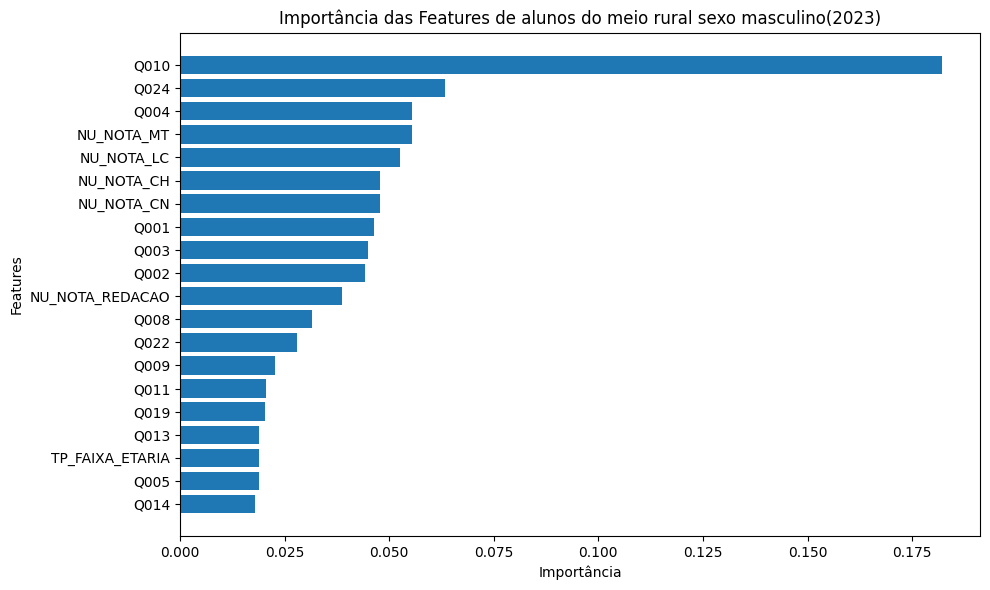

In [47]:
df_importancia_rural_homem = analisar_importancia_features_agregada(modelo_rural_homem,clf_rural_homem, "de alunos do meio rural sexo masculino(2023)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1704
NU_NOTA_MT: 0.0555
NU_NOTA_LC: 0.0527
Q024_A: 0.0522
NU_NOTA_CH: 0.0479
NU_NOTA_CN: 0.0477
NU_NOTA_REDACAO: 0.0388
Q004_D: 0.0345
Q008_B: 0.0195
TP_FAIXA_ETARIA: 0.0189
Q005: 0.0188
TP_COR_RACA: 0.0168
Q003_D: 0.0118
Q014_A: 0.0117
Q002_G: 0.0103
Q022_E: 0.0103
Q009_D: 0.0098
Q003_C: 0.0092
Q018_A: 0.0089
Q013_B: 0.0087


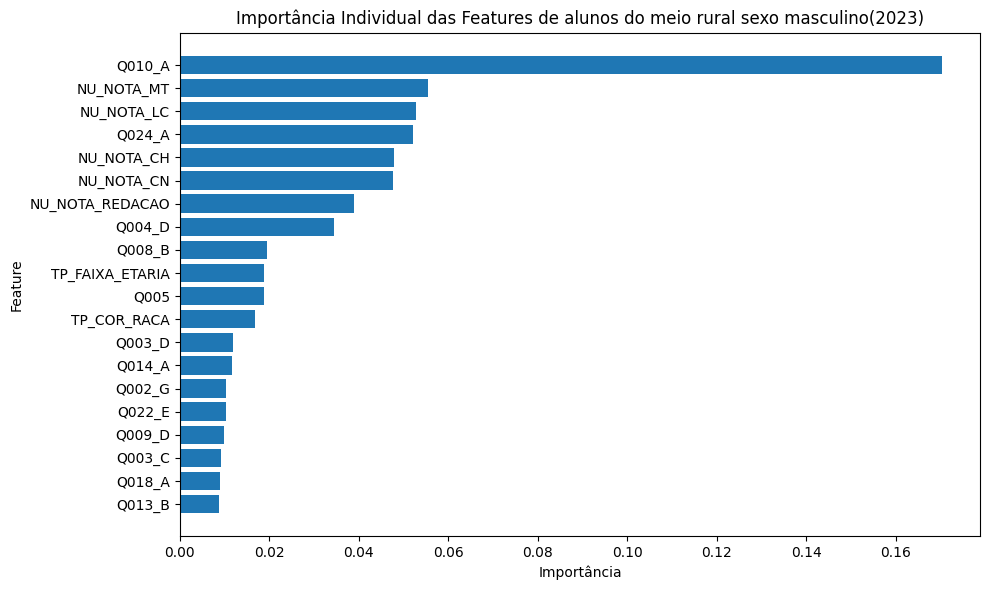

In [48]:
df_importancias_individuais_rural_homem = analisar_importancia_features(modelo_rural_homem, clf_rural_homem, "de alunos do meio rural sexo masculino(2023)", top_n=20)

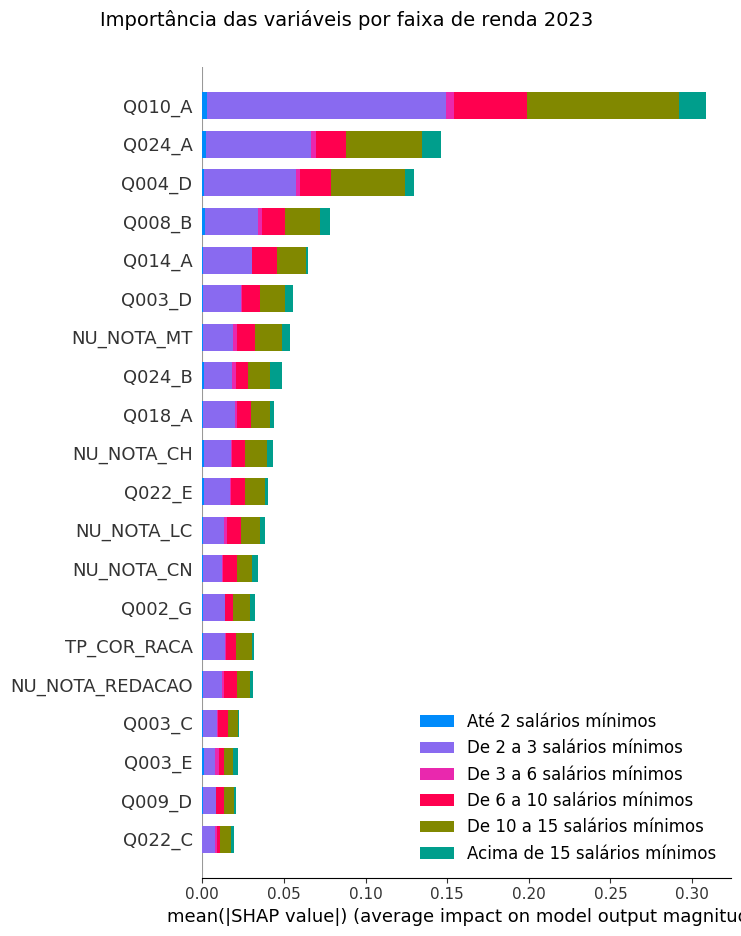

In [49]:
shap_multiclasses(df_transformado_rural_homem, clf_rural_homem, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


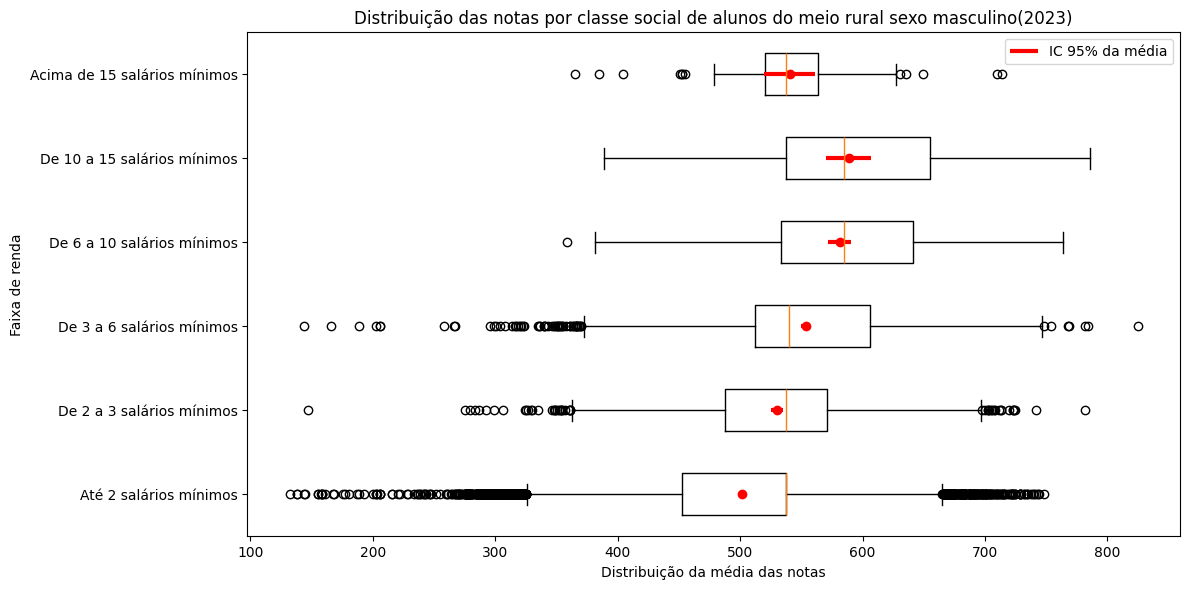

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,501.279912,537.777315,82.650264,12480,6831.066177,452.855000,537.777315,132.00000,748.06,616.06000,16.487847,1,0.739839,499.829855,502.729969
3,De 2 a 3 salários mínimos,530.391322,537.777315,79.700374,1027,6352.149644,487.190000,571.040000,147.18000,781.42,634.24000,15.026712,2,2.486996,525.516899,535.265745
4,De 3 a 6 salários mínimos,553.363160,540.020000,82.675775,2179,6835.283773,512.280000,606.370000,143.70000,824.62,680.92000,14.940600,3,1.771127,549.891815,556.834504
5,De 6 a 10 salários mínimos,581.351451,584.500000,79.616611,286,6338.804806,533.490000,641.445000,358.52000,764.08,405.56000,13.695091,4,4.707829,572.124276,590.578626
2,De 10 a 15 salários mínimos,588.581636,585.180000,84.459011,80,7133.324552,537.777315,655.430000,388.71745,785.90,397.18255,14.349583,5,9.442805,570.074079,607.089193
0,Acima de 15 salários mínimos,540.312606,537.777315,71.786600,46,5153.315996,520.055000,563.300000,364.73745,714.10,349.36255,13.286124,6,10.584357,519.567647,561.057564


In [18]:
analisar_desempenho_por_classe(dataset_rural_homem, "de alunos do meio rural sexo masculino(2023)")

In [51]:
modelo_rural_mulher, clf_rural_mulher, df_transformado_rural_mulher = treinar_modelo(dataset_rural_mulher)

Acurácia: 1.0

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        22
      Até 2 salários mínimos       1.00      1.00      1.00     16199
 De 10 a 15 salários mínimos       1.00      1.00      1.00        69
   De 2 a 3 salários mínimos       1.00      1.00      1.00      1024
   De 3 a 6 salários mínimos       1.00      1.00      1.00      1967
  De 6 a 10 salários mínimos       1.00      1.00      1.00       271

                    accuracy                           1.00     19552
                   macro avg       1.00      1.00      1.00     19552
                weighted avg       1.00      1.00      1.00     19552


Matriz de confusão:
 [[   22     0     0     0     0     0]
 [    0 16199     0     0     0     0]
 [    0     0    69     0     0     0]
 [    0     0     0  1024     0     0]
 [    0     0     0     0  1967     0]
 [    0     0     0     0     0   27

Importância das features (agregada):
Feature Q024: 0.1654
Feature Q010: 0.0692
Feature NU_NOTA_MT: 0.0634
Feature Q004: 0.0601
Feature NU_NOTA_CH: 0.0548
Feature NU_NOTA_CN: 0.0548
Feature NU_NOTA_LC: 0.0541
Feature NU_NOTA_REDACAO: 0.0471
Feature Q001: 0.0405
Feature Q002: 0.0398
Feature Q003: 0.0396
Feature Q022: 0.0316
Feature Q008: 0.0265
Feature Q005: 0.0249
Feature Q019: 0.0238
Feature Q009: 0.0206
Feature Q013: 0.0189
Feature TP_COR_RACA: 0.0180
Feature Q014: 0.0180
Feature TP_FAIXA_ETARIA: 0.0166


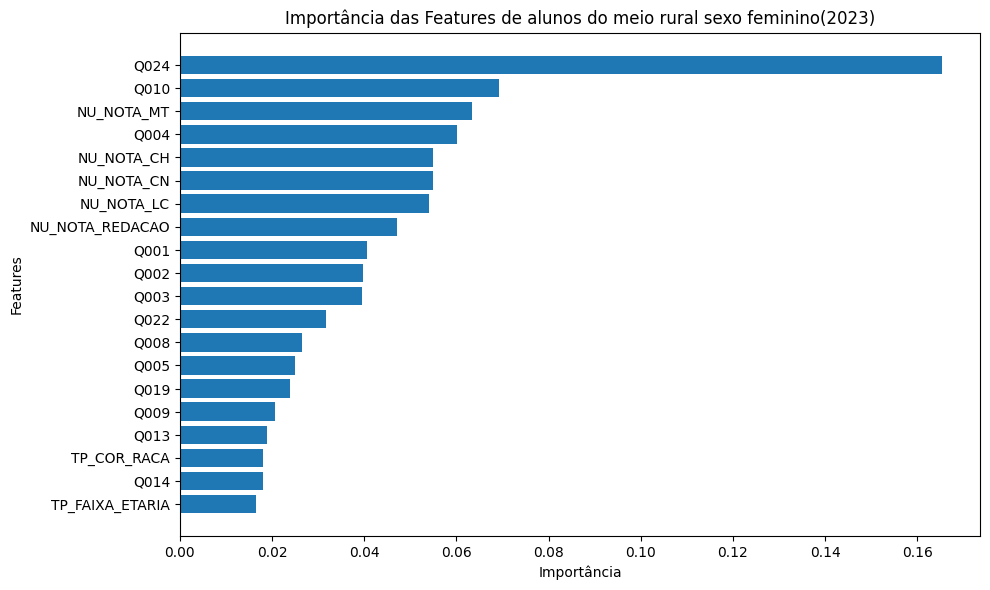

In [52]:
df_importancia_rural_mulher = analisar_importancia_features_agregada(modelo_rural_mulher,clf_rural_mulher, "de alunos do meio rural sexo feminino(2023)", top_n=20)

Importância das features (sem agregação):
Q024_A: 0.1573
NU_NOTA_MT: 0.0634
Q010_A: 0.0595
NU_NOTA_CH: 0.0548
NU_NOTA_CN: 0.0548
NU_NOTA_LC: 0.0541
NU_NOTA_REDACAO: 0.0471
Q004_D: 0.0361
Q005: 0.0249
TP_COR_RACA: 0.0180
TP_FAIXA_ETARIA: 0.0166
Q008_B: 0.0157
Q014_A: 0.0149
Q003_D: 0.0127
Q002_G: 0.0108
Q022_E: 0.0098
Q022_D: 0.0097
Q001_E: 0.0094
Q009_D: 0.0088
Q019_C: 0.0084


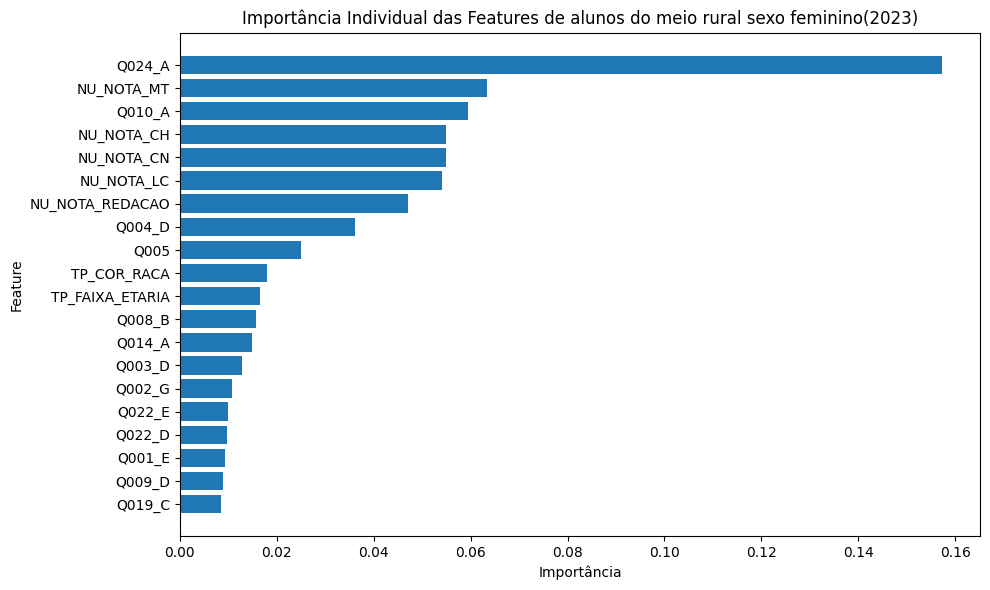

In [53]:
df_importancias_individuais_rural_mulher = analisar_importancia_features(modelo_rural_mulher, clf_rural_mulher, "de alunos do meio rural sexo feminino(2023)", top_n=20)

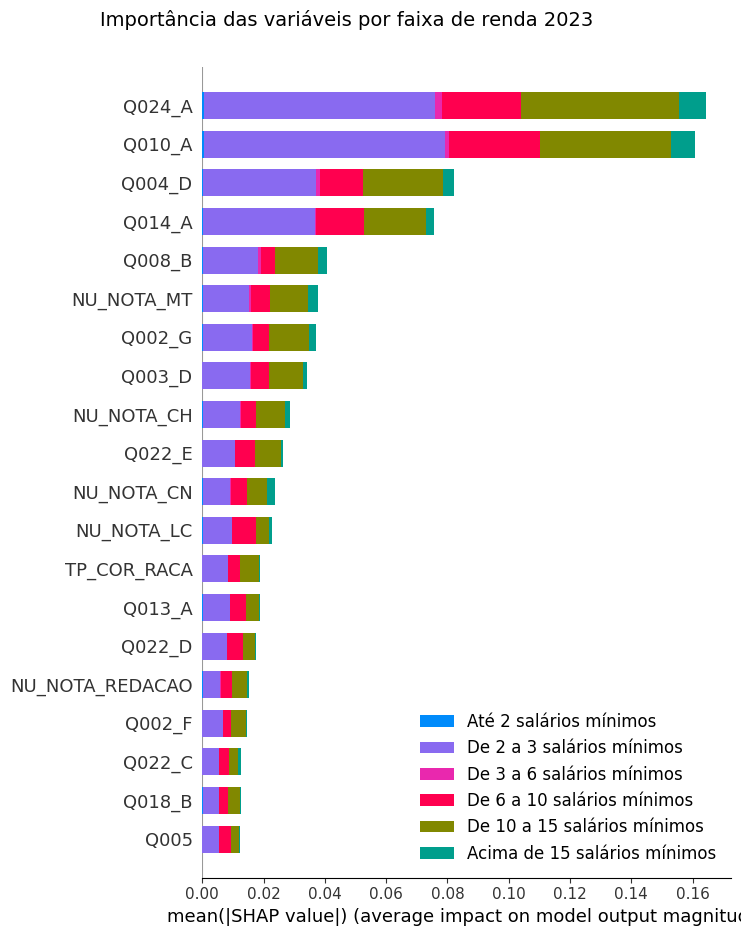

In [54]:
shap_multiclasses(df_transformado_rural_mulher, clf_rural_mulher, "2023")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_16120\3049995716.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


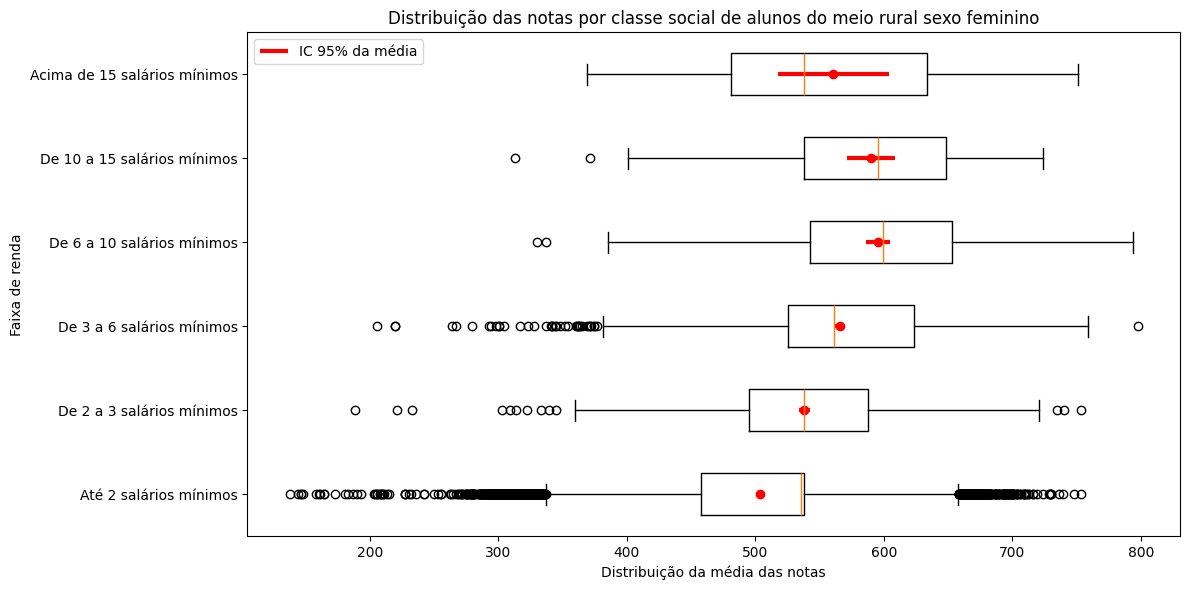

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,503.522448,535.240000,75.034288,16199,5630.144405,457.428725,537.777315,137.68000,753.90,616.22000,14.901875,1,0.589543,502.366964,504.677931
3,De 2 a 3 salários mínimos,538.331316,537.777315,75.129266,1024,5644.406574,494.920000,587.730000,188.60000,753.26,564.66000,13.955953,2,2.347790,533.729733,542.932899
4,De 3 a 6 salários mínimos,565.811381,561.180000,78.777947,1967,6205.964993,525.708725,623.320000,205.91745,797.58,591.66255,13.923005,3,1.776243,562.330008,569.292754
5,De 6 a 10 salários mínimos,595.773436,599.760000,79.469244,271,6315.360753,542.410000,653.110000,330.46000,794.14,463.68000,13.338836,4,4.827413,586.311881,605.234991
2,De 10 a 15 salários mínimos,589.966065,595.240000,78.121644,69,6102.991229,537.777315,648.640000,313.30000,724.30,411.00000,13.241718,5,9.404741,571.533112,608.399019
0,Acima de 15 salários mínimos,560.732904,537.777315,102.945414,22,10597.758287,481.200000,633.920000,368.86000,751.44,382.58000,18.359082,6,21.948036,517.715544,603.750264


In [19]:
analisar_desempenho_por_classe(dataset_rural_mulher, "de alunos do meio rural sexo feminino")